# Feature Correlation Analysis — Full

Covers all feature families, all subregions, all GLCM/GLDM/NGTDM distances,
cross-subregion redundancy, Oracle input features specifically, and VIF.

**Sections:**
1. Per-family within-subregion (WT, TC, ET × all families)
2. Cross-subregion (same feature, WT vs TC vs ET)
3. Oracle input features (the 258 features actually used)
4. VIF on Oracle features
5. Summary + suggested de-correlated feature set

**Outputs:**
- `../../Results/Figures/correlation_<family>_<subregion>.pdf`
- `../../Results/Figures/correlation_oracle_inputs.pdf`
- `../../Results/Figures/correlation_cross_subregion.pdf`
- `../../Results/Json_summary/summary_correlations.json`
- `../../Results/features_oracle_decorrelated.pkl` — cleaned Oracle feature list

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.patches import Patch
from scipy.stats import spearmanr
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform
import pickle as pkl
import json
import warnings
warnings.filterwarnings('ignore')
print('Libraries loaded.')

Libraries loaded.


## Helper Functions

In [14]:
def load_radiomics(subregion, family):
    """Load a radiomics pickle → flat DataFrame (patients × features).
    Column names include the family suffix to match Oracle feature naming convention:
    e.g. original_shape_Sphericity_flair_shape, original_ngtdm_Strength_flair_ngtdm_10
    """
    path = f'../../Results/Analysis_Results/Radiomics/{subregion}/{family}.pkl'
    with open(path, 'rb') as f:
        raw = pkl.load(f)
    frames = []
    for feat_name, patient_dict in raw.items():
        df = pd.DataFrame.from_dict(patient_dict, orient='index').astype(float)
        df.columns = [f'{feat_name}_{col}_{family}' for col in df.columns]
        frames.append(df)
    return pd.concat(frames, axis=1)


def spearman_matrix(df):
    """Spearman correlation matrix on clean numeric columns."""
    clean = df.apply(pd.to_numeric, errors='coerce').dropna(axis=1, how='all').dropna()
    if clean.shape[1] < 2:
        return pd.DataFrame([[1.0]], index=clean.columns, columns=clean.columns), clean
    corr, _ = spearmanr(clean)
    return pd.DataFrame(corr, index=clean.columns, columns=clean.columns), clean


def high_corr_pairs(corr_df, threshold=0.9):
    """Upper-triangle pairs where |r| >= threshold, sorted by |r| desc."""
    cols = corr_df.columns.tolist()
    pairs = []
    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):
            r = corr_df.iloc[i, j]
            if abs(r) >= threshold:
                pairs.append((cols[i], cols[j], round(float(r), 4)))
    return sorted(pairs, key=lambda x: -abs(x[2]))


def greedy_drop(corr_df, threshold=0.9):
    """Greedy: drop the feature with higher mean |r| when a pair exceeds threshold."""
    to_drop = set()
    cols = corr_df.columns.tolist()
    mean_abs = corr_df.abs().mean()
    for i in range(len(cols)):
        if cols[i] in to_drop:
            continue
        for j in range(i + 1, len(cols)):
            if cols[j] in to_drop:
                continue
            if abs(corr_df.iloc[i, j]) >= threshold:
                drop = cols[j] if mean_abs[cols[j]] >= mean_abs[cols[i]] else cols[i]
                to_drop.add(drop)
    return to_drop


def compute_vif(df):
    """Variance Inflation Factor for each feature column."""
    from numpy.linalg import lstsq
    clean = df.apply(pd.to_numeric, errors='coerce').dropna(axis=1, how='all').dropna()
    X = clean.values
    X = (X - X.mean(axis=0)) / (X.std(axis=0) + 1e-10)
    vif = {}
    for i, col in enumerate(clean.columns):
        y = X[:, i]
        Xother = np.delete(X, i, axis=1)
        coef, _, _, _ = lstsq(Xother, y, rcond=None)
        y_hat = Xother @ coef
        ss_res = np.sum((y - y_hat) ** 2)
        ss_tot = np.sum((y - y.mean()) ** 2)
        r2 = 1 - ss_res / ss_tot if ss_tot > 0 else 0
        vif[col] = round(1 / (1 - r2 + 1e-10), 2)
    return pd.Series(vif).sort_values(ascending=False)


def clustered_heatmap(corr_df, title, max_labels=50):
    """Clustered heatmap, returns fig."""
    n = corr_df.shape[0]
    labels = []
    for c in corr_df.columns:
        parts = c.split('_')
        labels.append('_'.join(parts[2:4]) if len(parts) >= 4 else c)

    dist = np.clip(1 - corr_df.abs().values, 0, None)
    np.fill_diagonal(dist, 0)
    try:
        Z = linkage(squareform(dist), method='ward')
        order = dendrogram(Z, no_plot=True)['leaves']
    except Exception:
        order = list(range(n))

    corr_ord   = corr_df.iloc[order, order]
    labels_ord = [labels[i] for i in order]
    show = n <= max_labels

    sz = max(7, n * 0.17)
    fig, ax = plt.subplots(figsize=(sz, sz))
    sns.heatmap(corr_ord, ax=ax, cmap='RdBu_r', vmin=-1, vmax=1, center=0,
                xticklabels=labels_ord if show else False,
                yticklabels=labels_ord if show else False,
                linewidths=0 if n > 30 else 0.3,
                square=True, cbar_kws={'shrink': 0.6})
    ax.set_title(title, fontsize=10, pad=8)
    if show:
        ax.tick_params(axis='x', labelsize=6, rotation=90)
        ax.tick_params(axis='y', labelsize=6)
    plt.tight_layout()
    return fig


print('Helper functions loaded.')

Helper functions loaded.


## Section 1 — Per-Family, Per-Subregion Correlation
All families × all subregions (WT, TC, ET). Covers all GLCM/GLDM/NGTDM distance variants.

In [15]:
SUBREGIONS = ['Tumor_WT', 'Tumor_TC', 'Tumor_ET']
SR_LABELS  = {'Tumor_WT': 'WT', 'Tumor_TC': 'TC', 'Tumor_ET': 'ET'}

FAMILIES = [
    'shape', 'size', 'firstorder', 'intensity',
    'glcm_1', 'glcm_5', 'glcm_10',
    'gldm_1', 'gldm_5', 'gldm_10',
    'glrlm', 'glszm',
    'ngtdm_1', 'ngtdm_5', 'ngtdm_10',
]

THRESHOLD = 0.9
summary = {}  # {subregion: {family: stats}}

SEP60 = '=' * 60
DASH60 = '-' * 60

for sr in SUBREGIONS:
    sr_label = SR_LABELS[sr]
    summary[sr_label] = {}
    print(SEP60)
    print(f'Subregion: {sr_label}')
    print(f'{"Family":15s}  {"Feats":>6}  {"Pairs(|r|>=0.9)":>16}  {"Drop":>6}  {"Keep":>6}')
    print(DASH60)

    for fam in FAMILIES:
        try:
            df = load_radiomics(sr, fam)
        except FileNotFoundError:
            continue

        corr_df, clean = spearman_matrix(df)
        if clean.shape[1] < 2:
            continue

        pairs   = high_corr_pairs(corr_df, THRESHOLD)
        to_drop = greedy_drop(corr_df, THRESHOLD)
        kept    = clean.shape[1] - len(to_drop)

        print(f'{fam:15s}  {clean.shape[1]:>6}  {len(pairs):>16}  {len(to_drop):>6}  {kept:>6}')

        summary[sr_label][fam] = {
            'n_features':        int(clean.shape[1]),
            'n_high_corr_pairs': len(pairs),
            'n_suggested_drops': len(to_drop),
            'n_retained':        int(kept),
            'top_pairs':         [{'a': a, 'b': b, 'r': r} for a, b, r in pairs[:10]],
            'suggested_drops':   sorted(list(to_drop)),
        }


Subregion: WT
Family            Feats   Pairs(|r|>=0.9)    Drop    Keep
------------------------------------------------------------
shape                36                54      27       9
size                 24               132      21       3
firstorder           72               169      46      26
intensity            12                 4       3       9
glcm_1               96               343      65      31
glcm_5               96               398      69      27
glcm_10              96               418      69      27
gldm_1               56                70      27      29
gldm_5               56                53      21      35
gldm_10              56                44      19      37
glrlm                64               138      42      22
glszm                64               113      40      24
ngtdm_1              20                 9       8      12
ngtdm_5              20                10       7      13
ngtdm_10             20                 9       7      

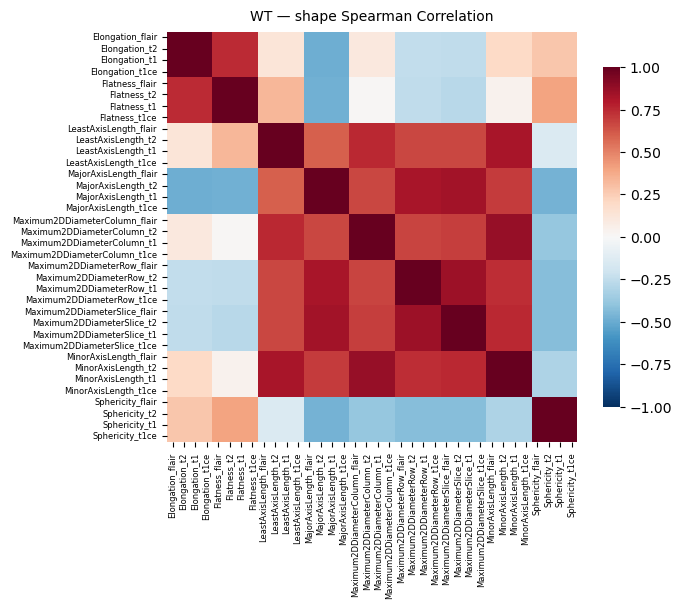

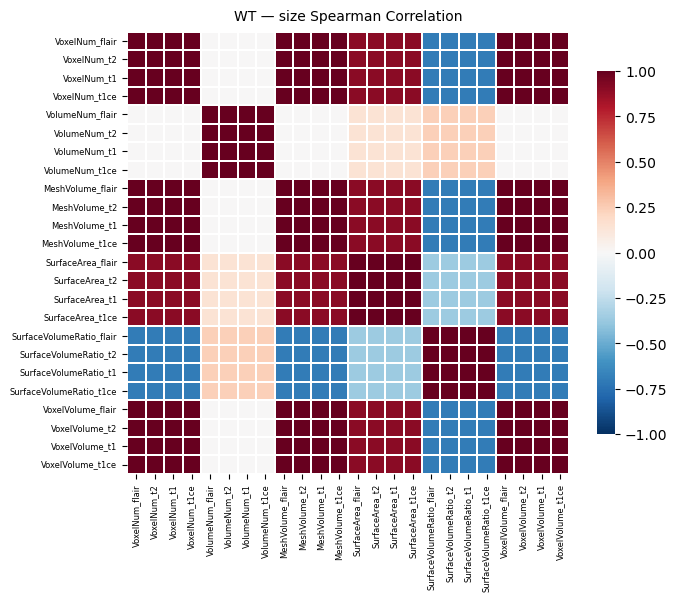

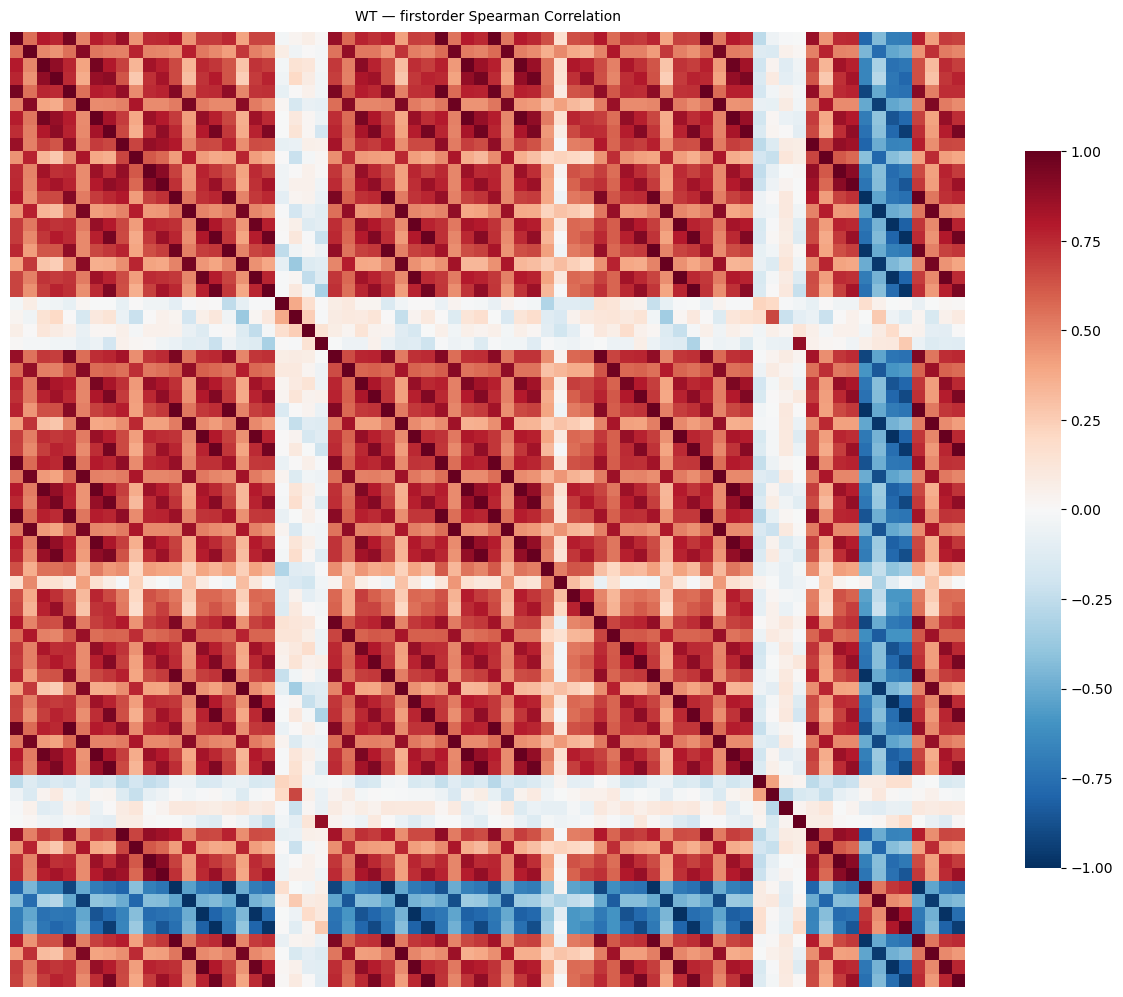

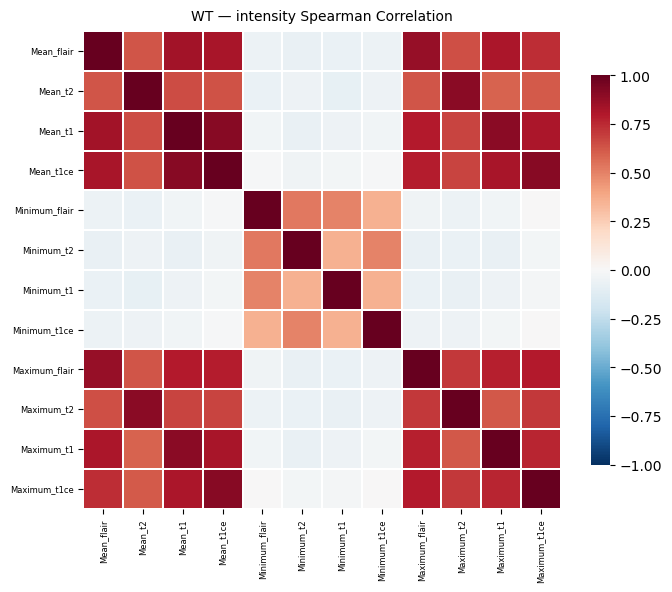

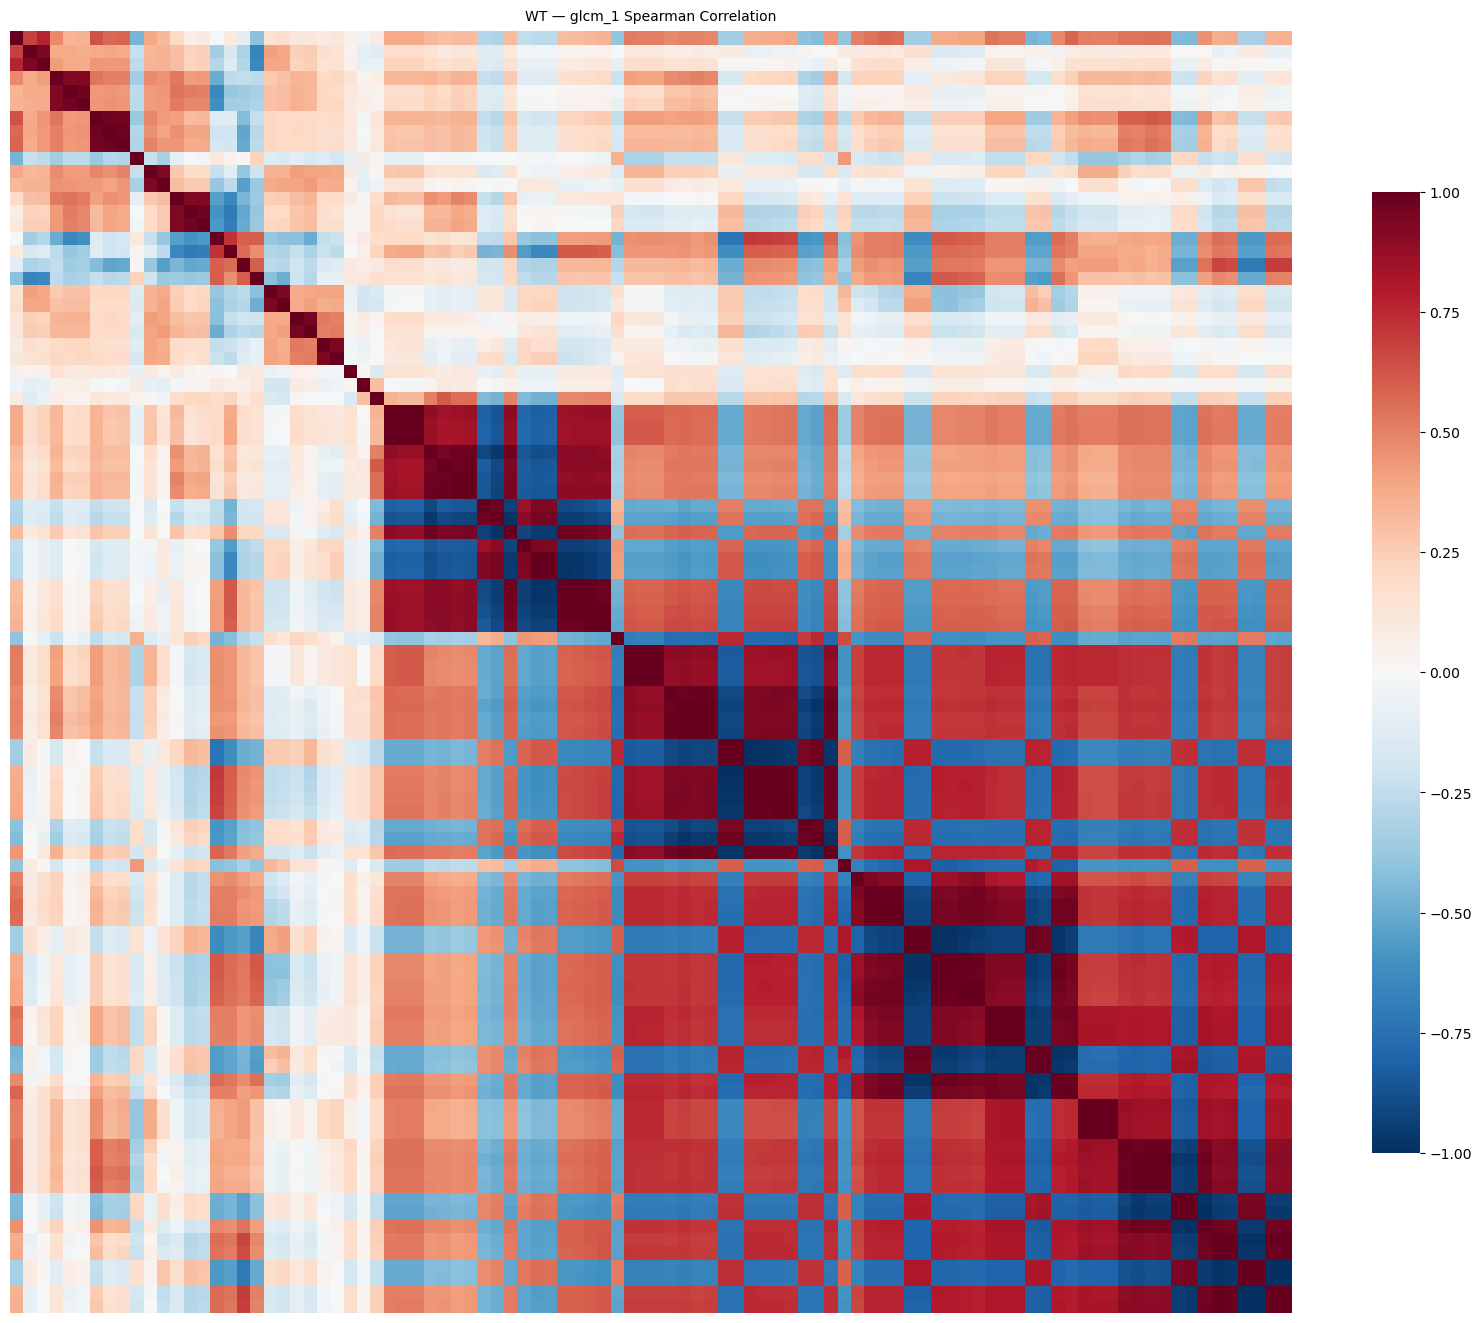

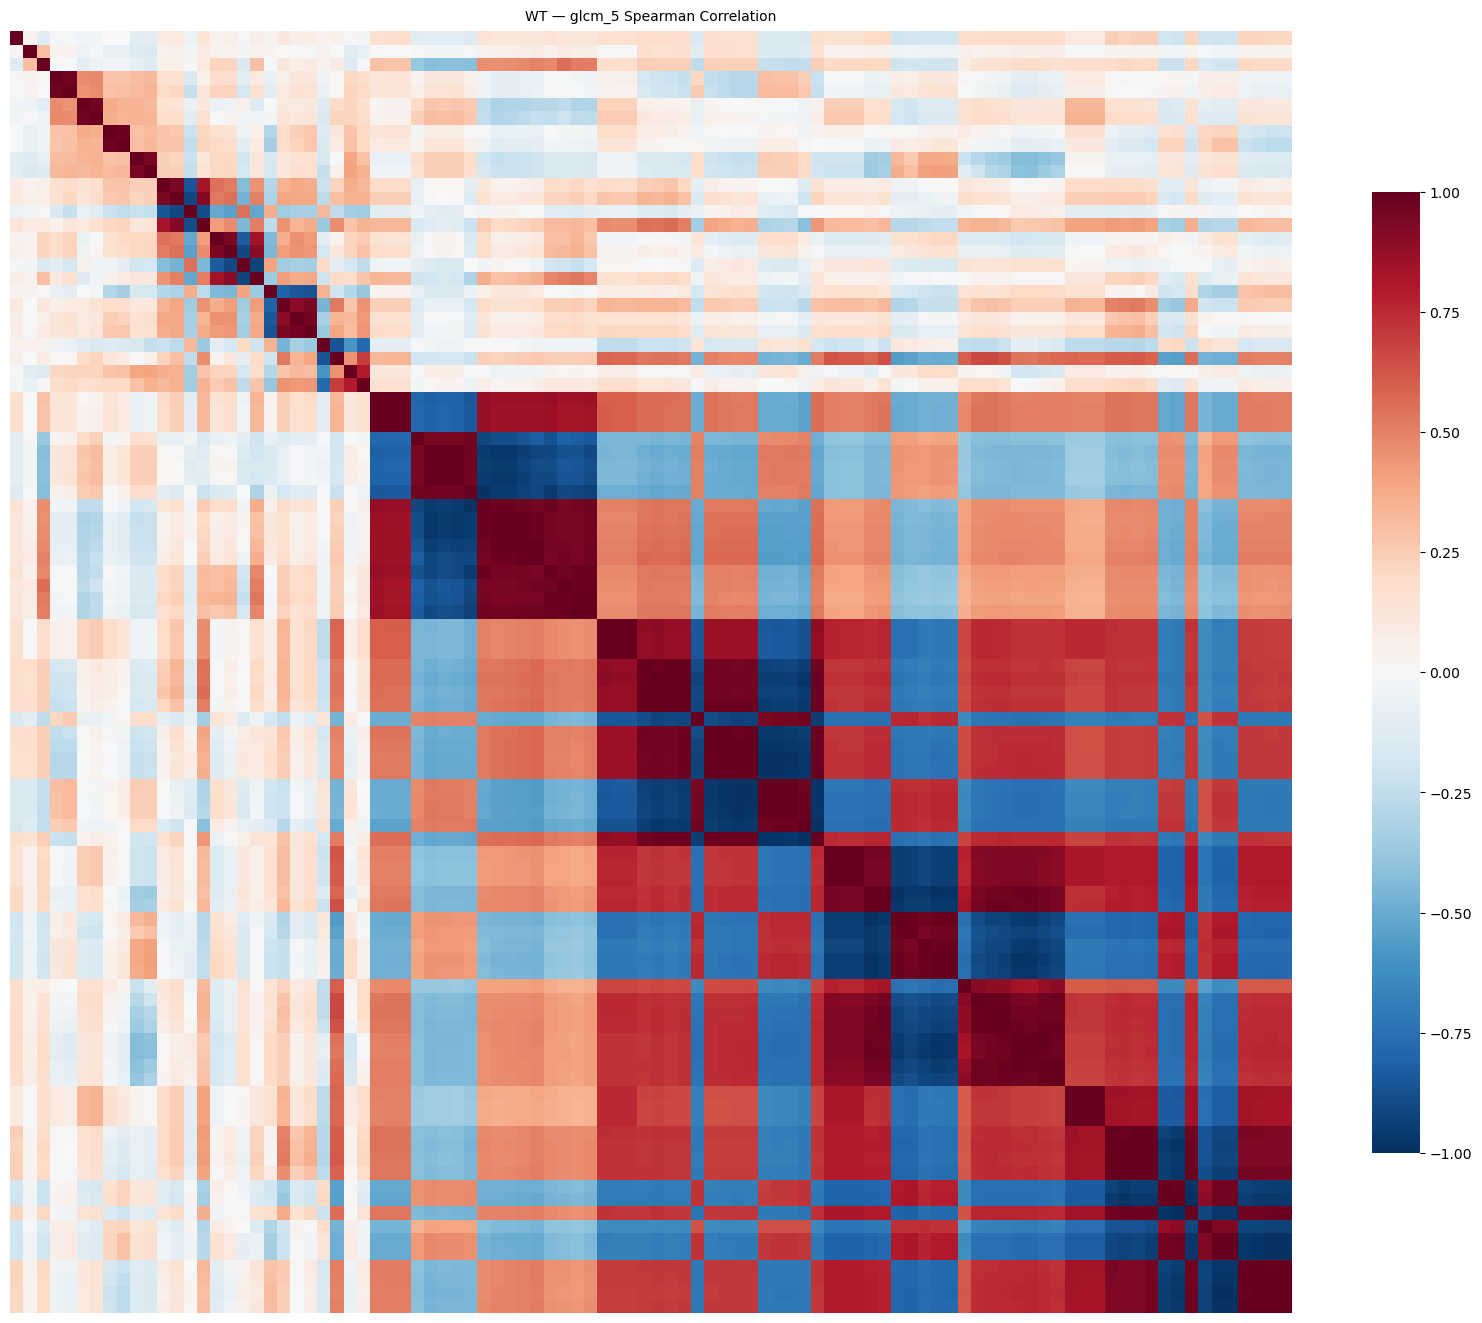

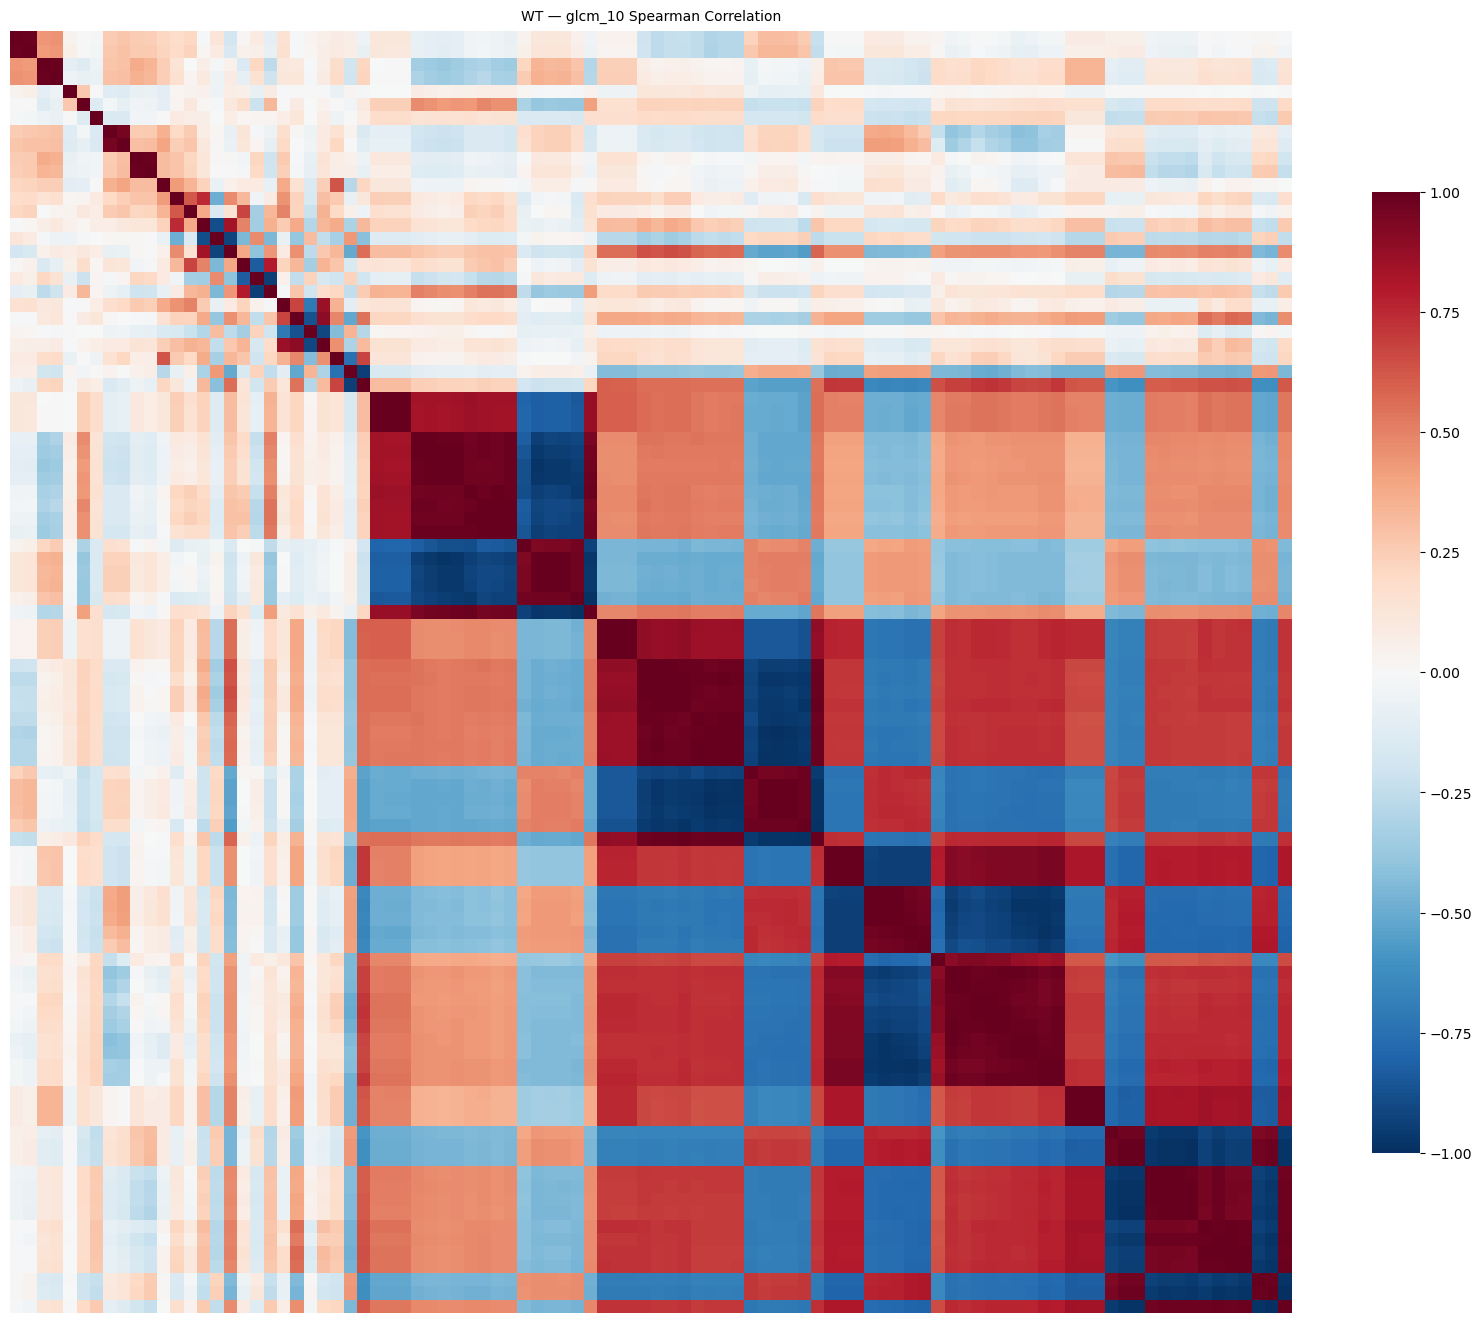

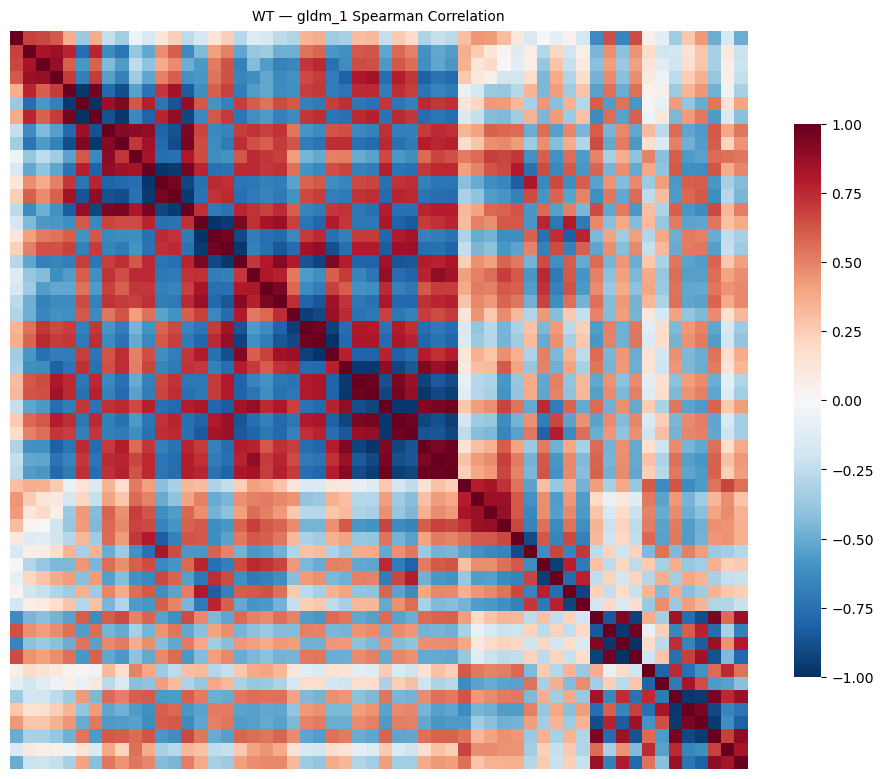

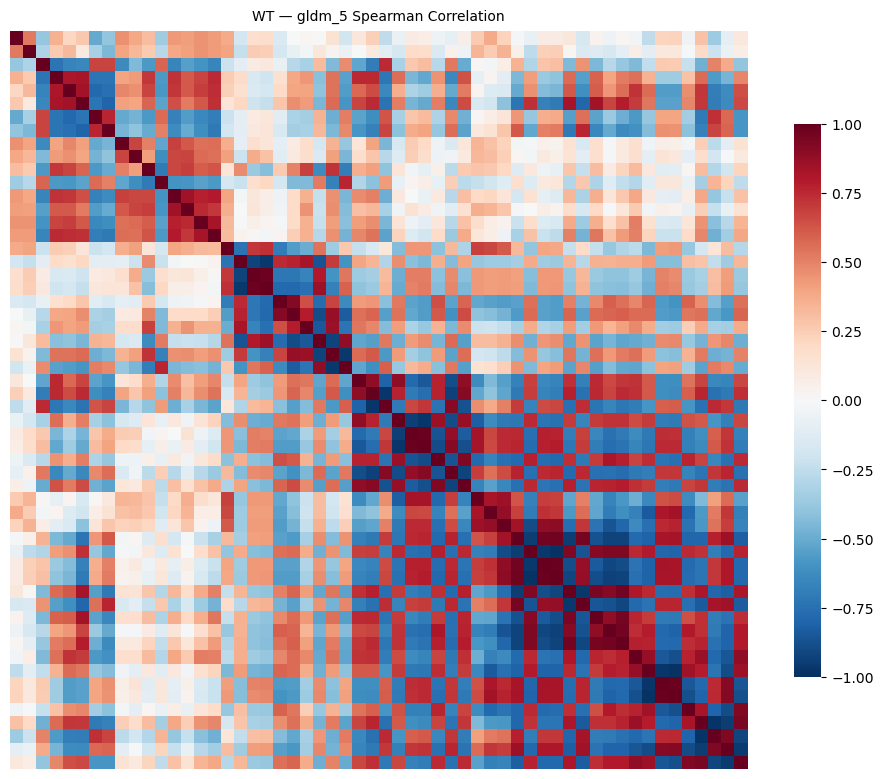

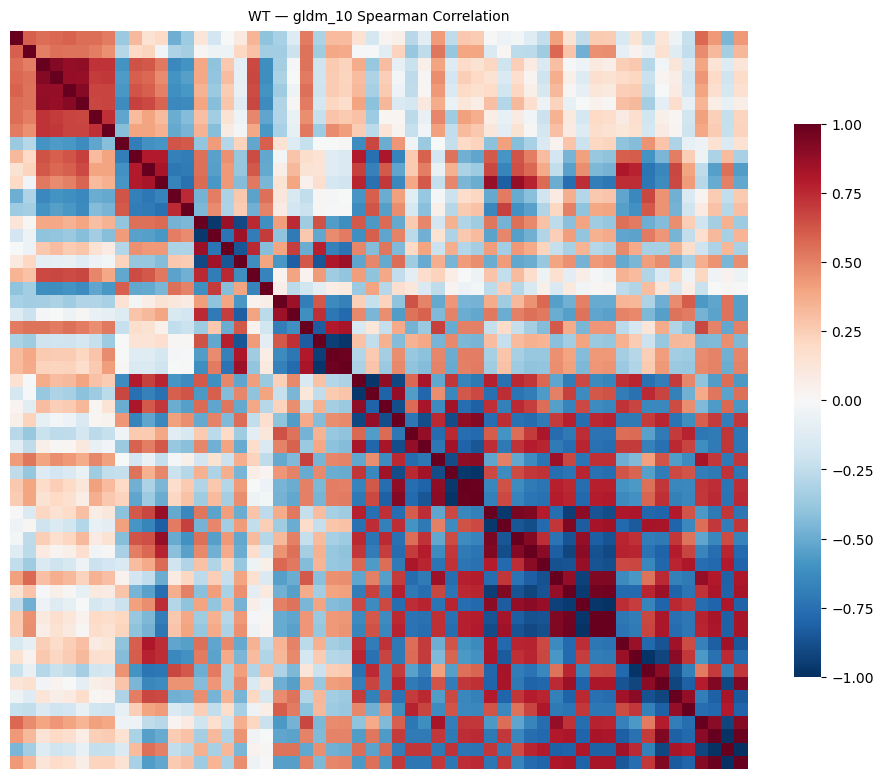

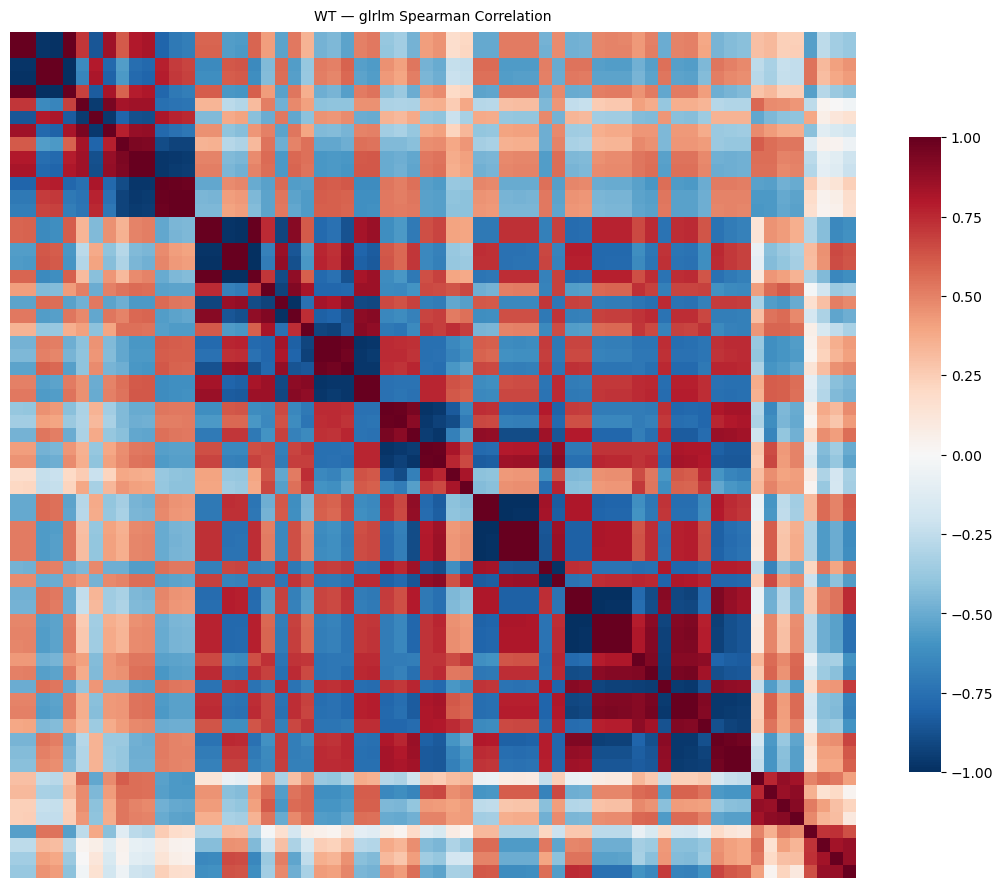

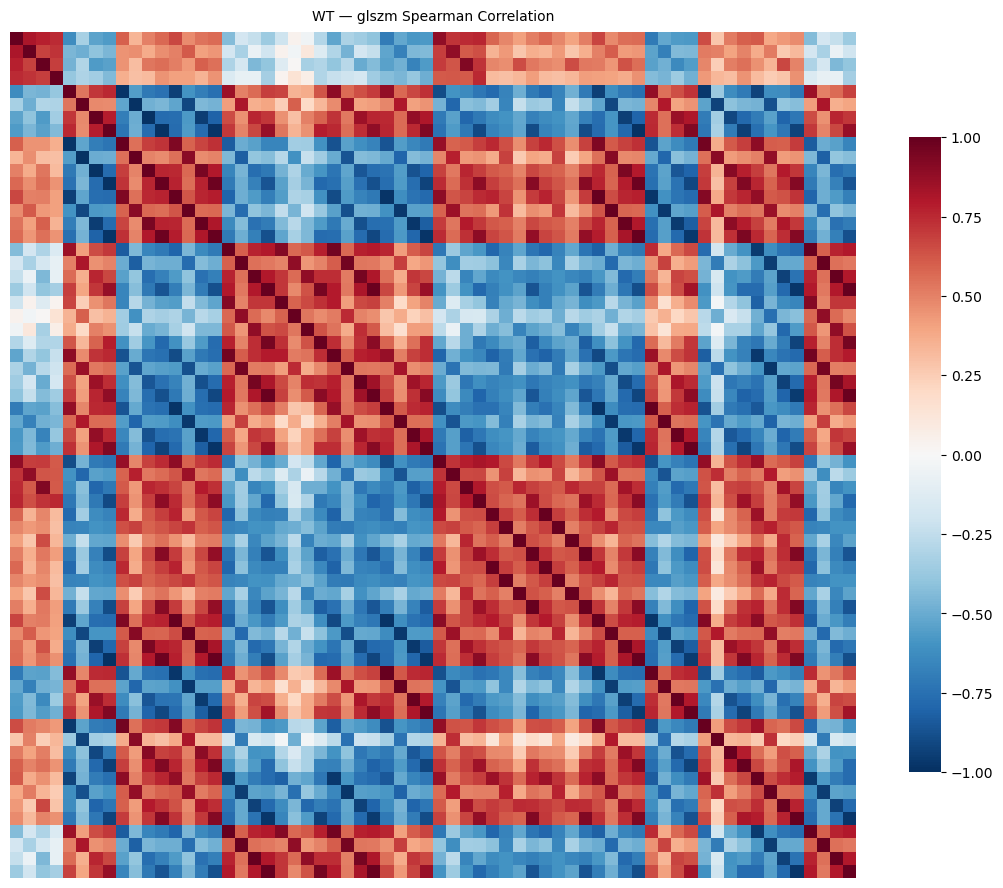

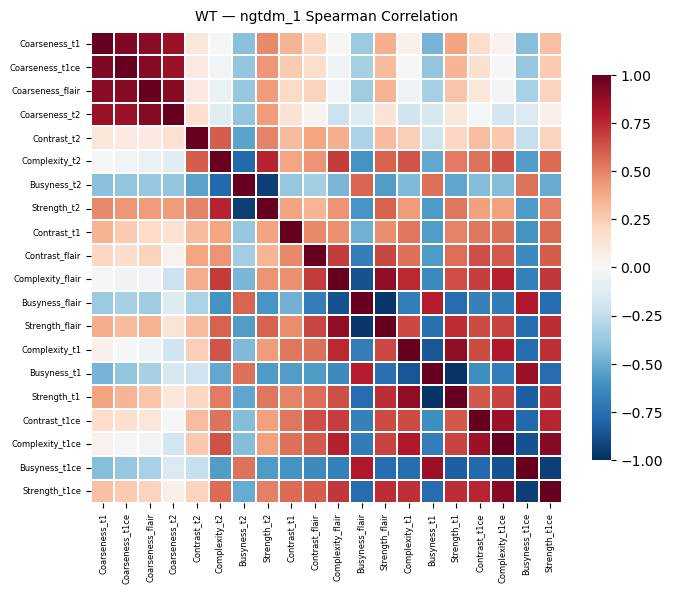

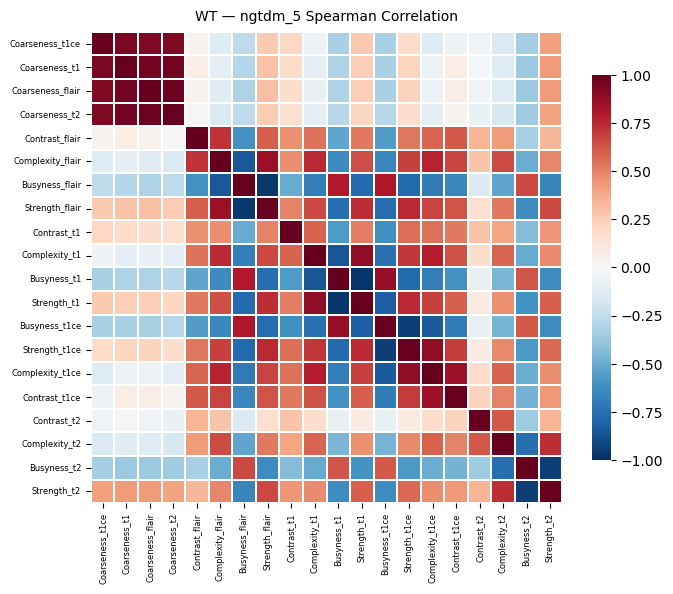

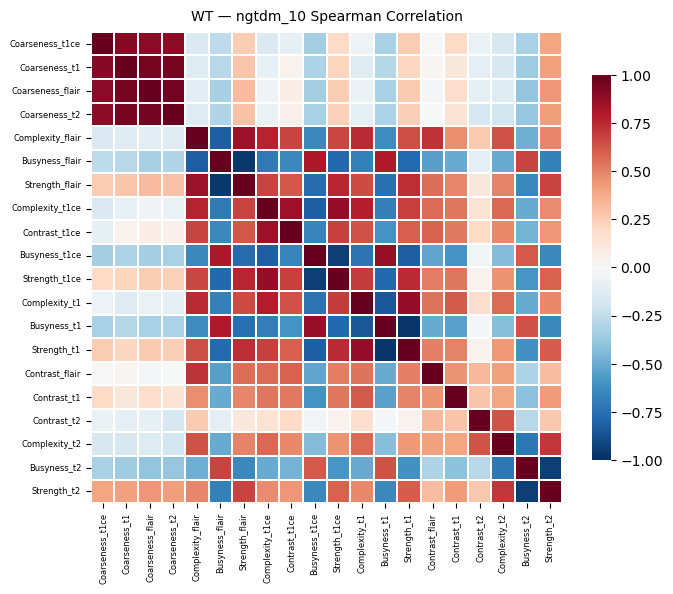

Saved: ../../Results/Figures/correlation_wt_all_families.pdf


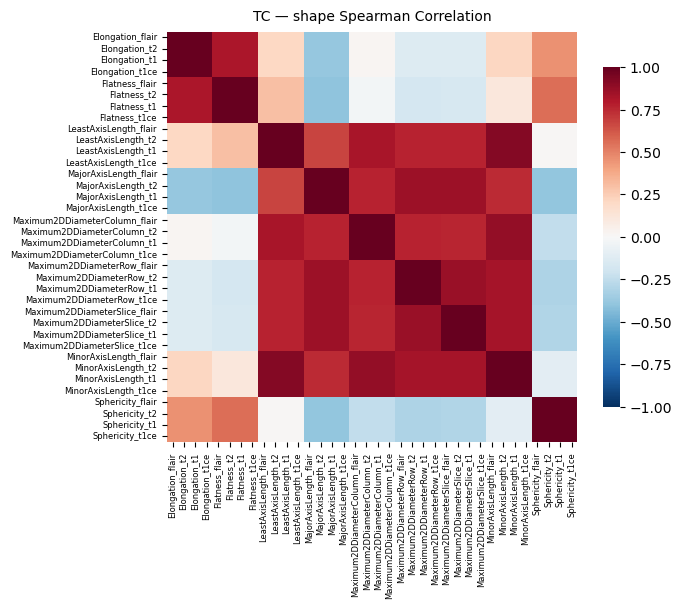

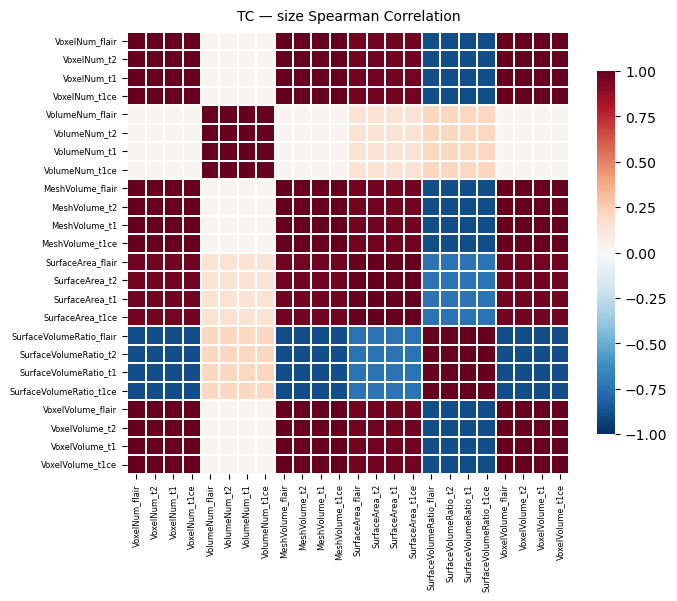

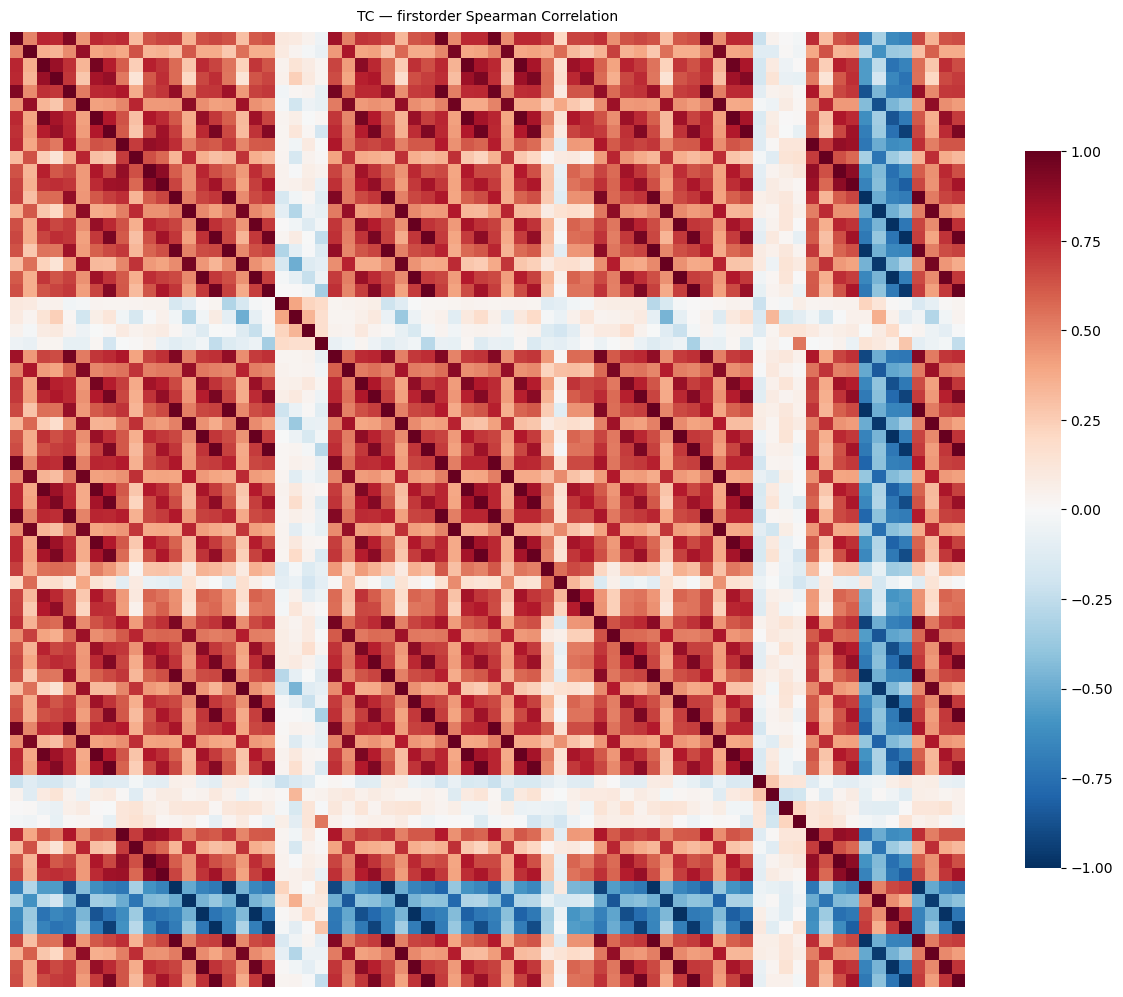

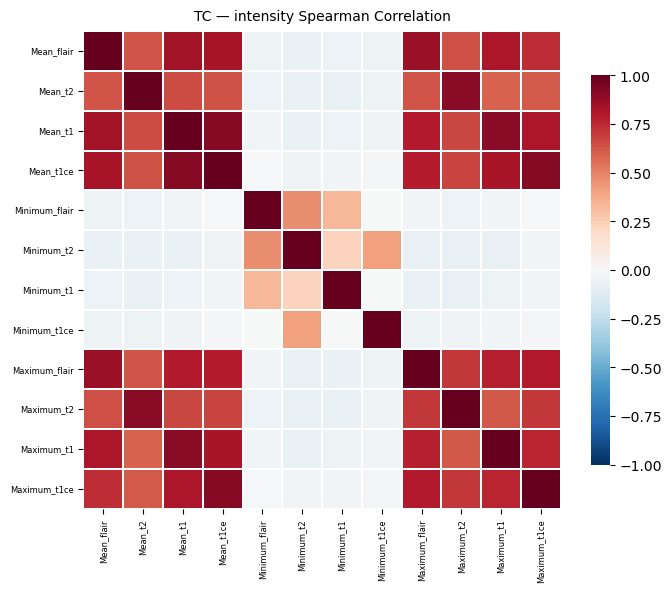

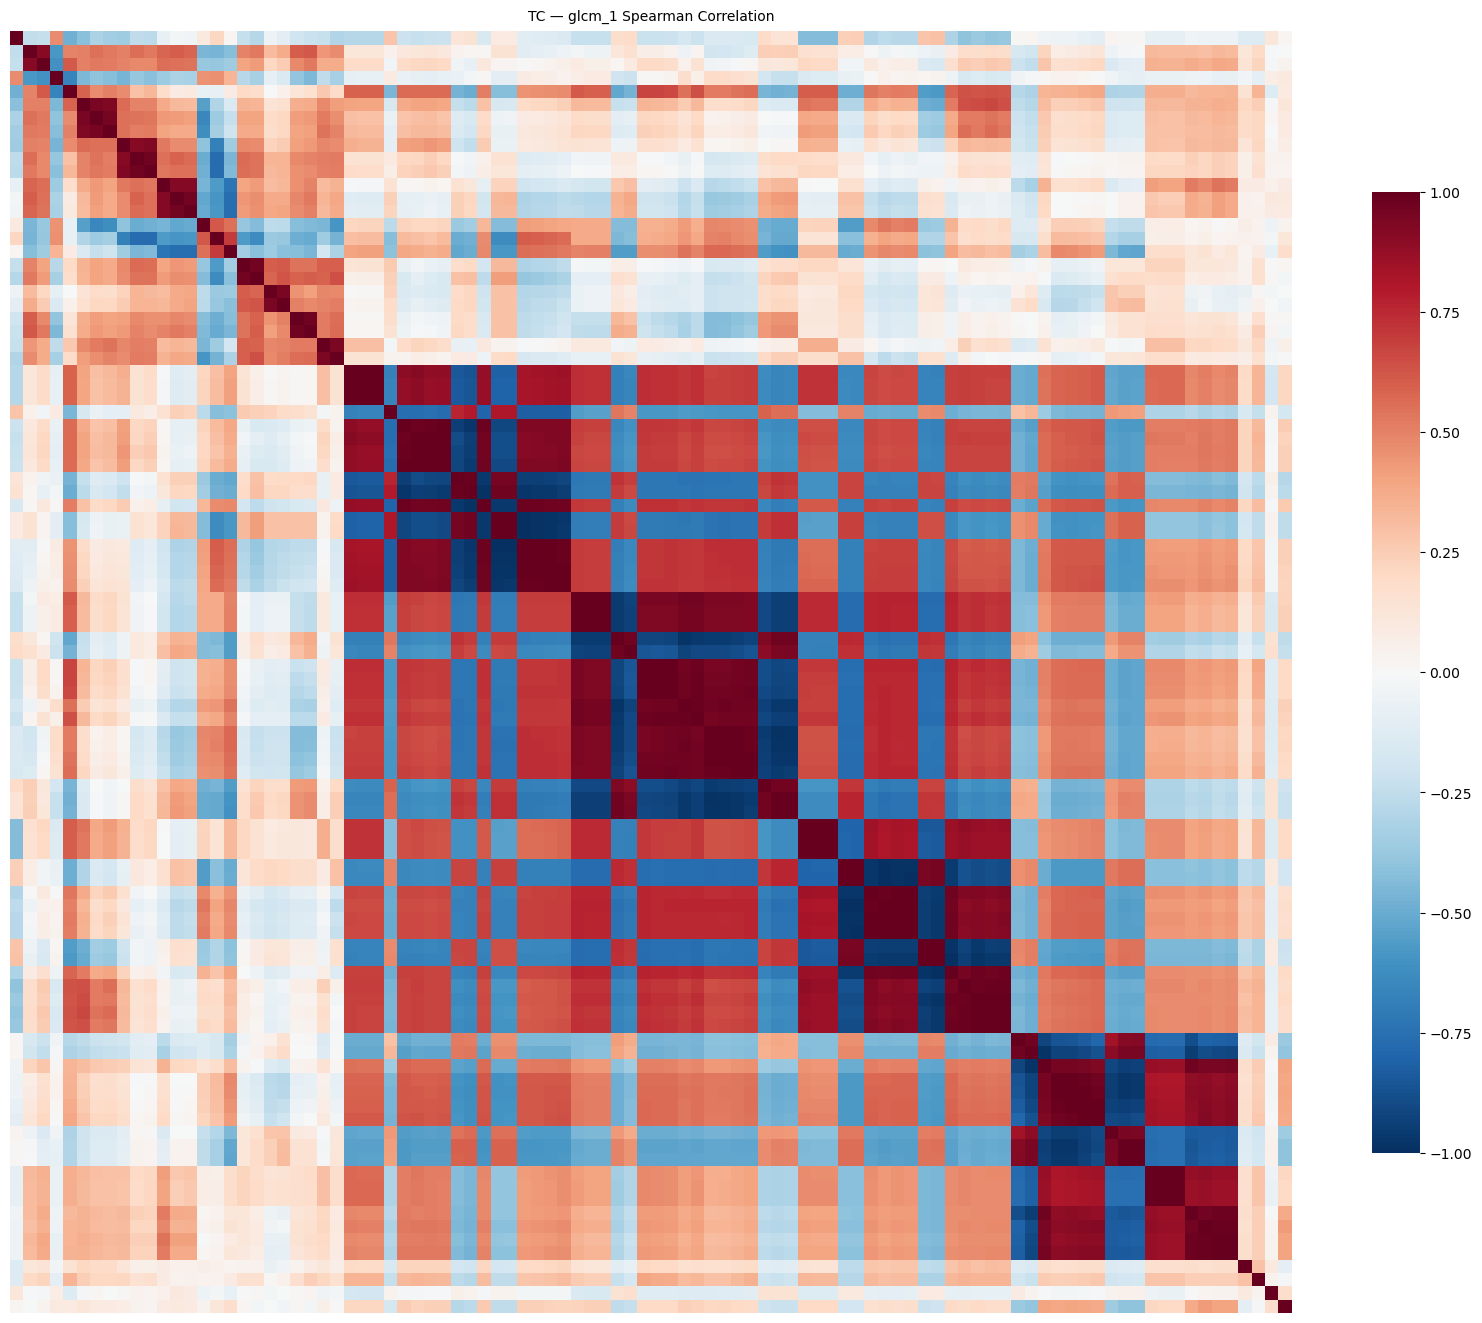

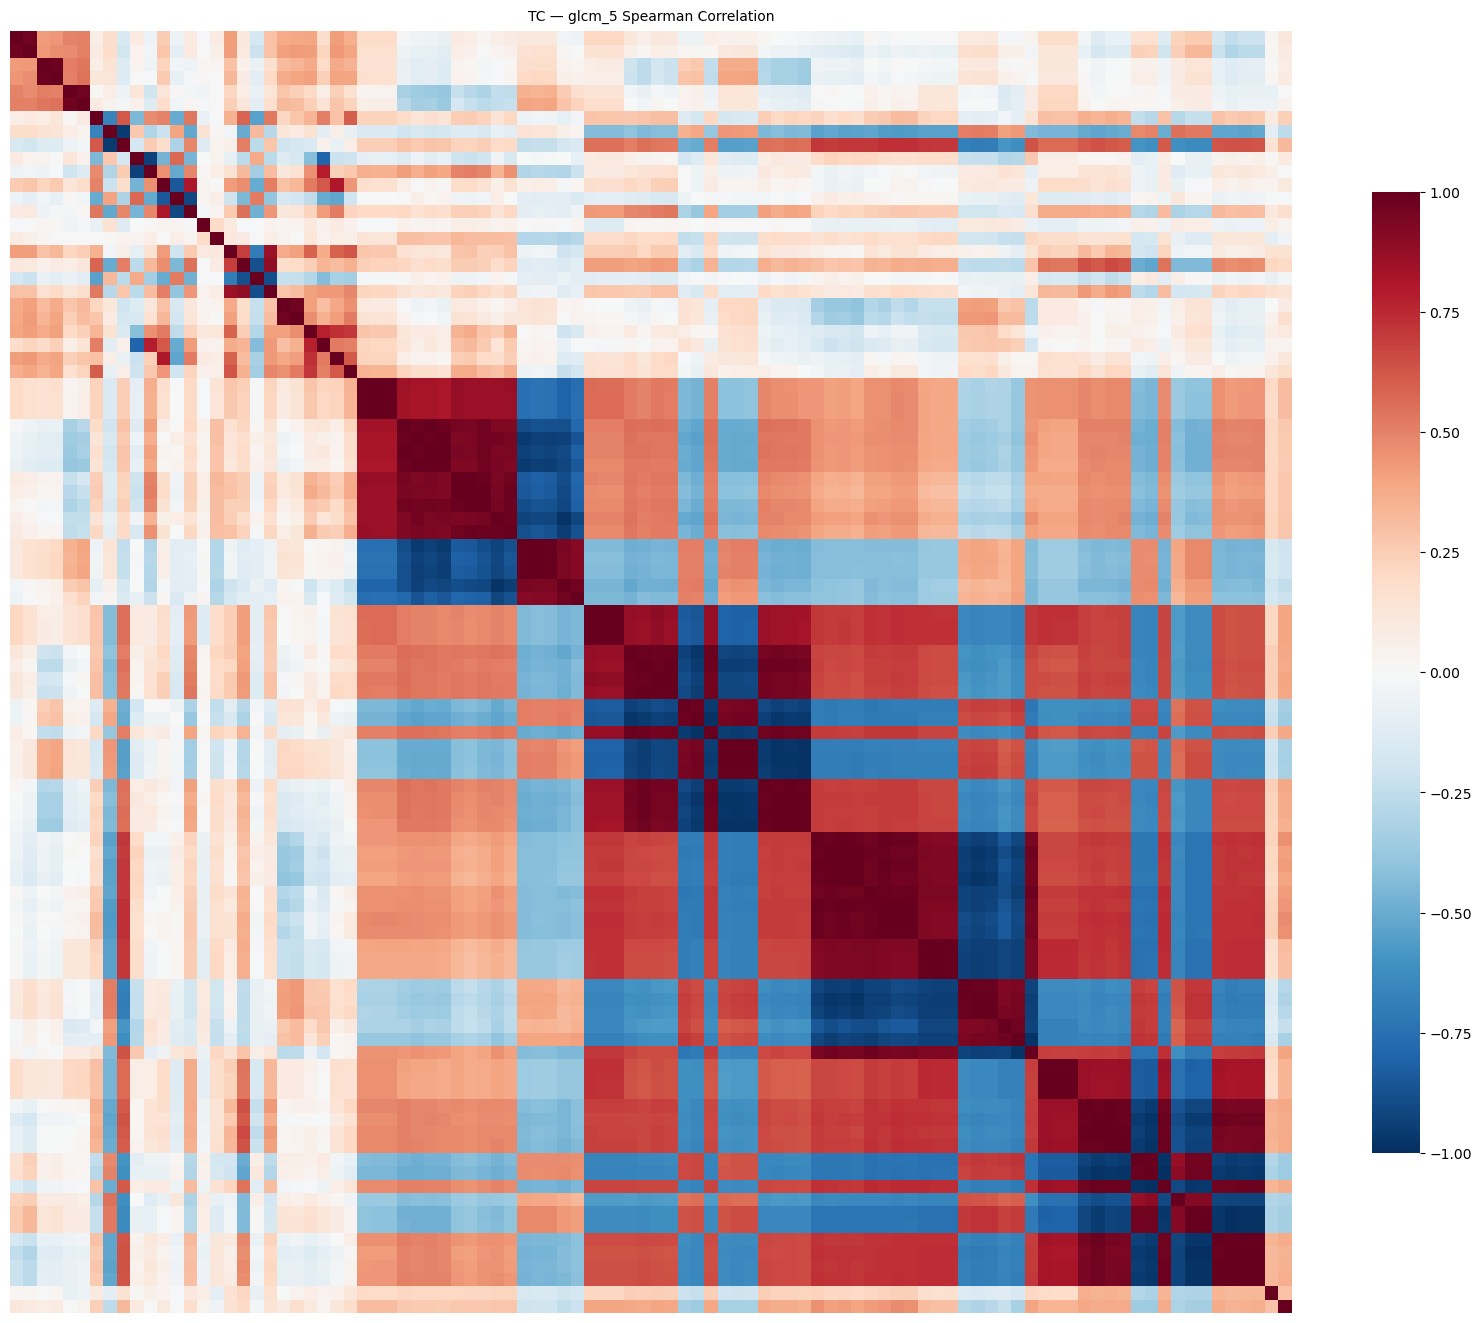

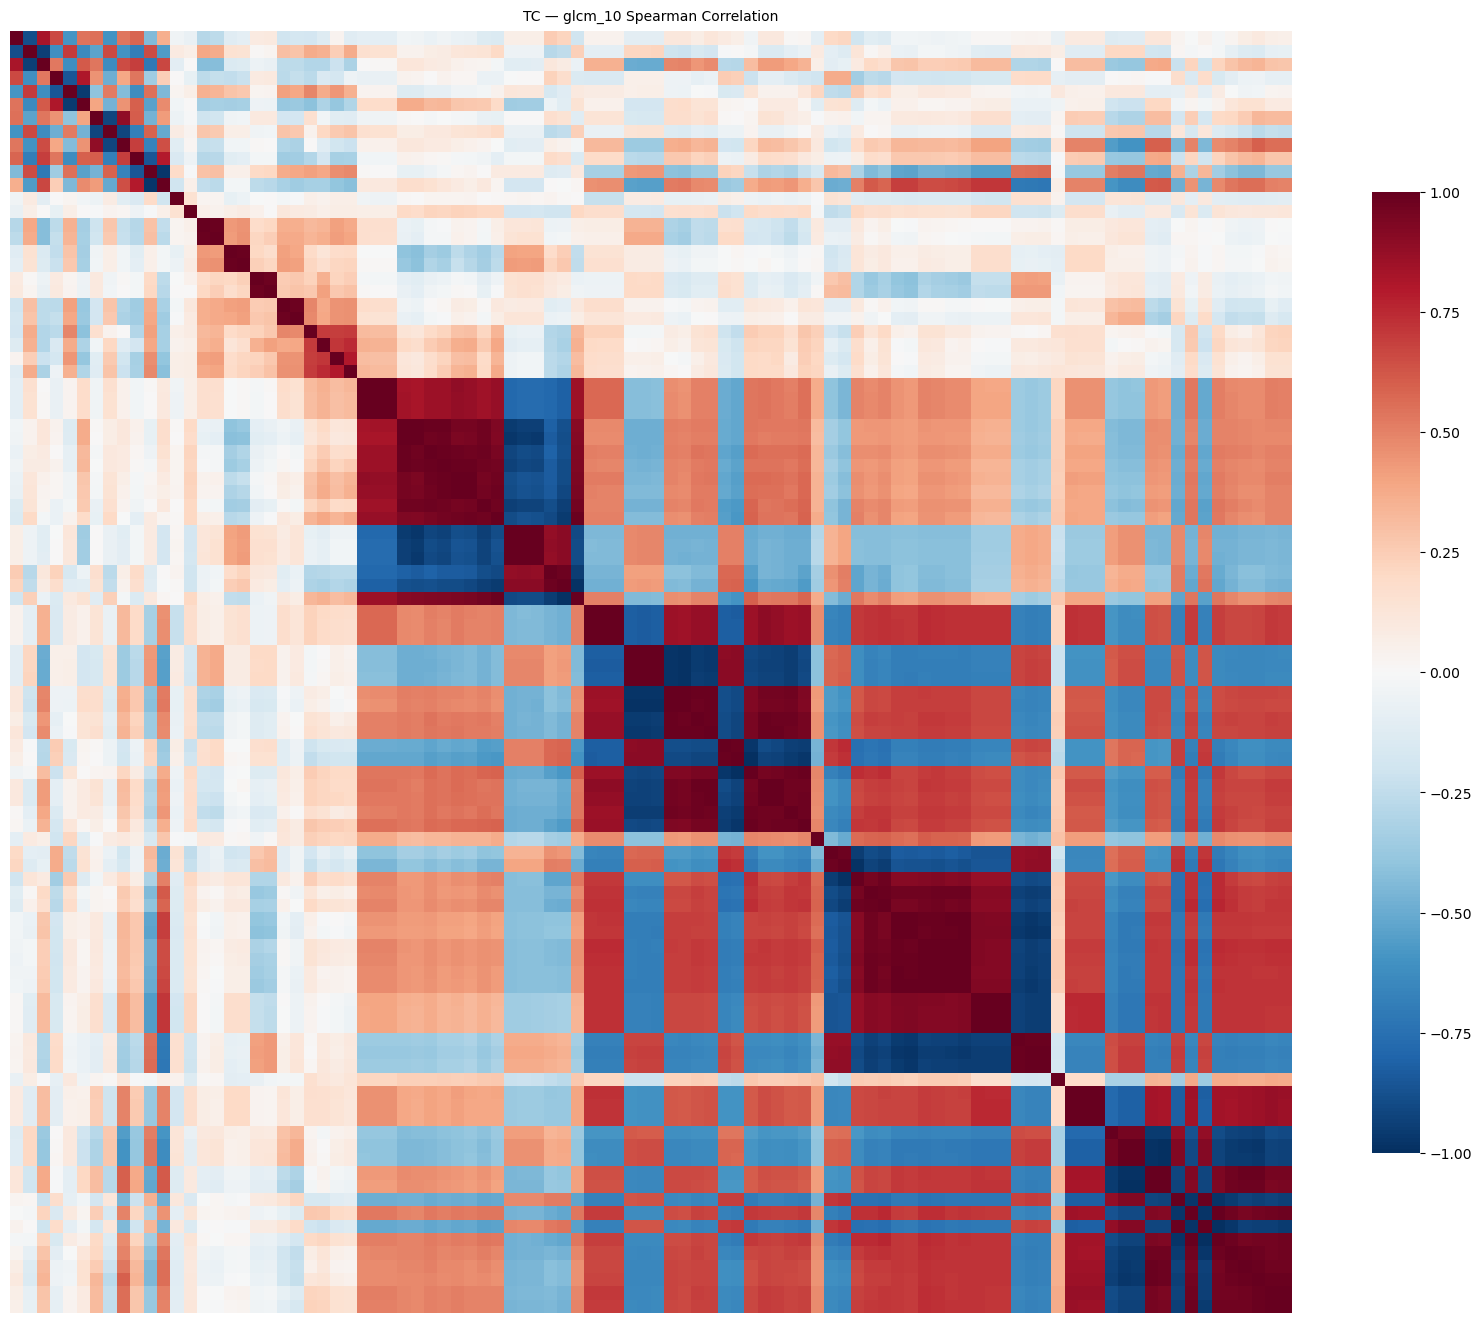

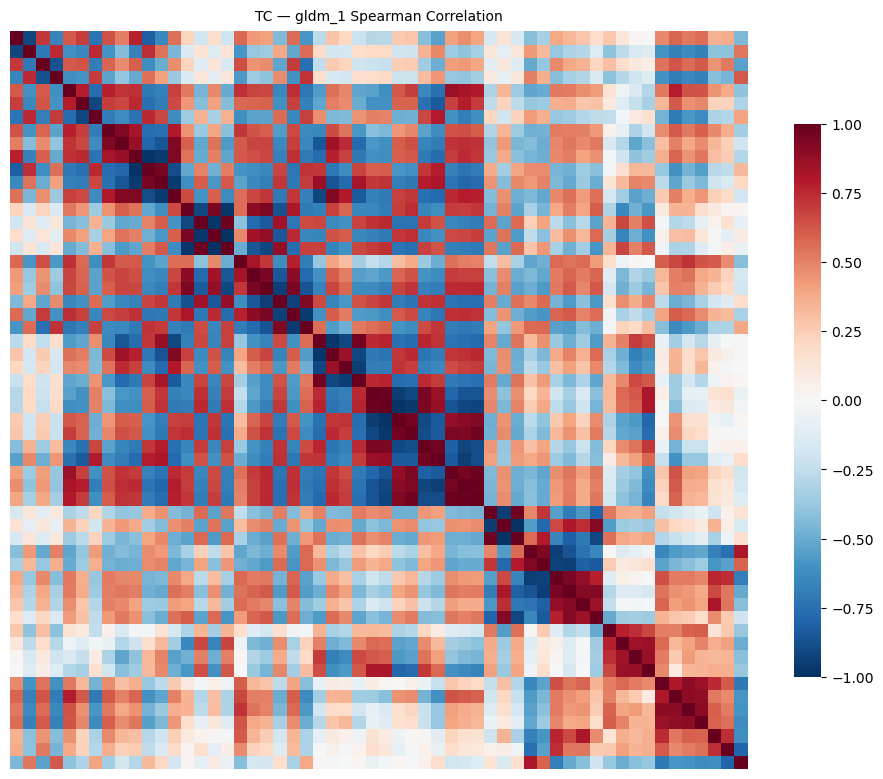

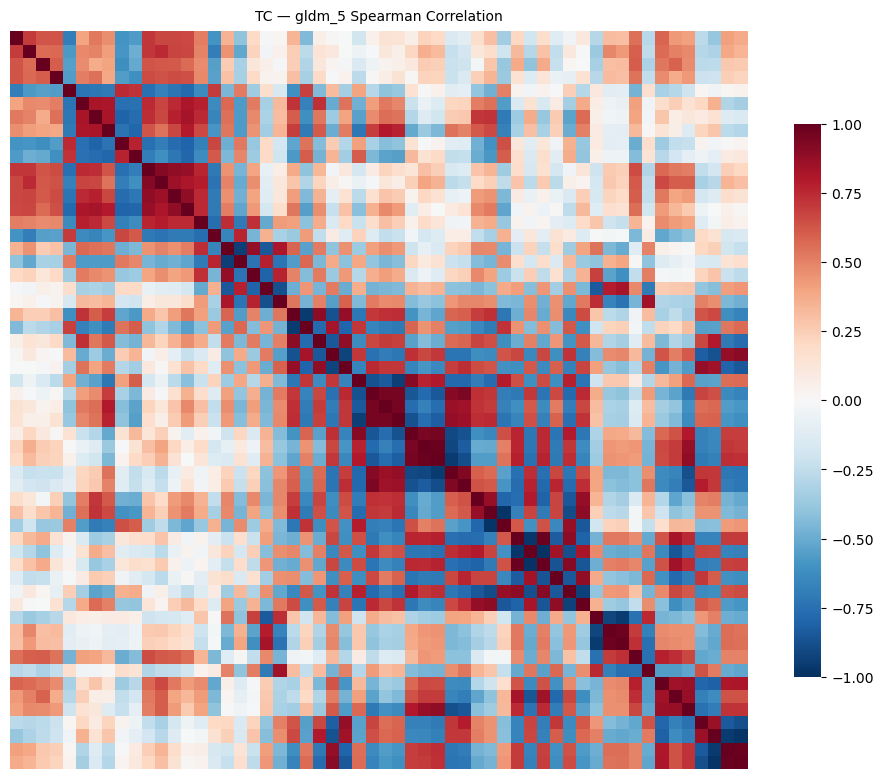

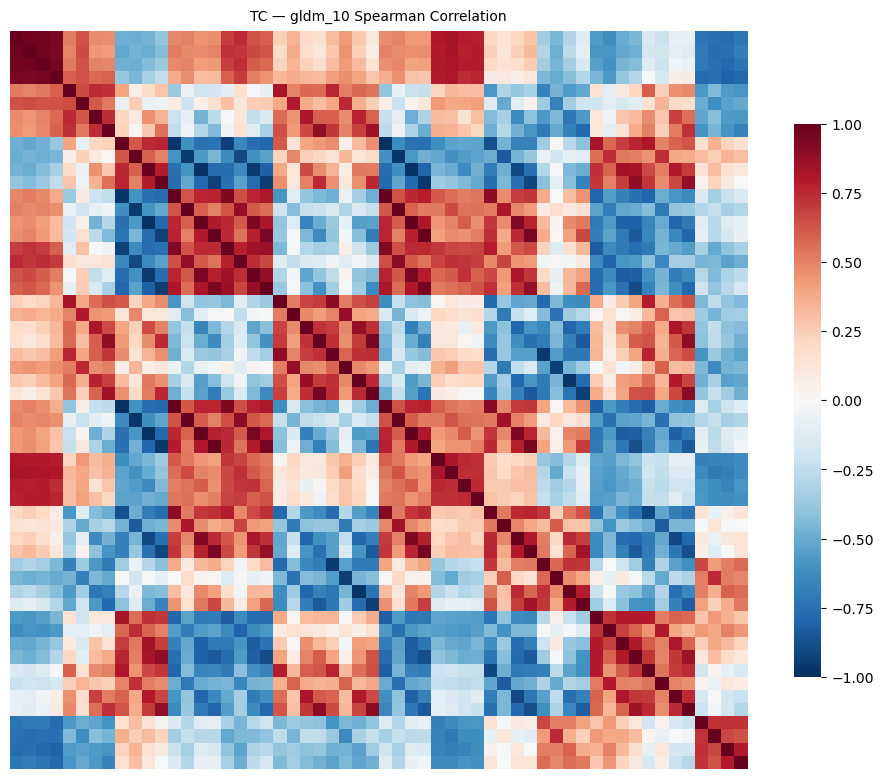

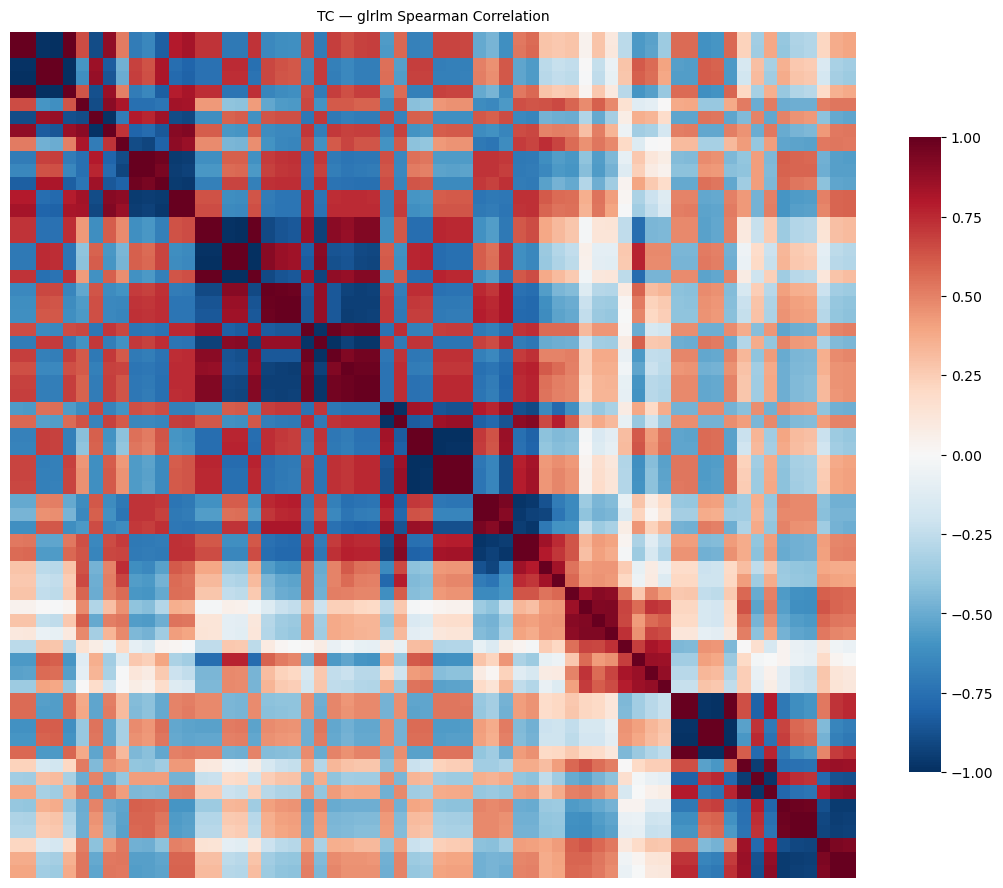

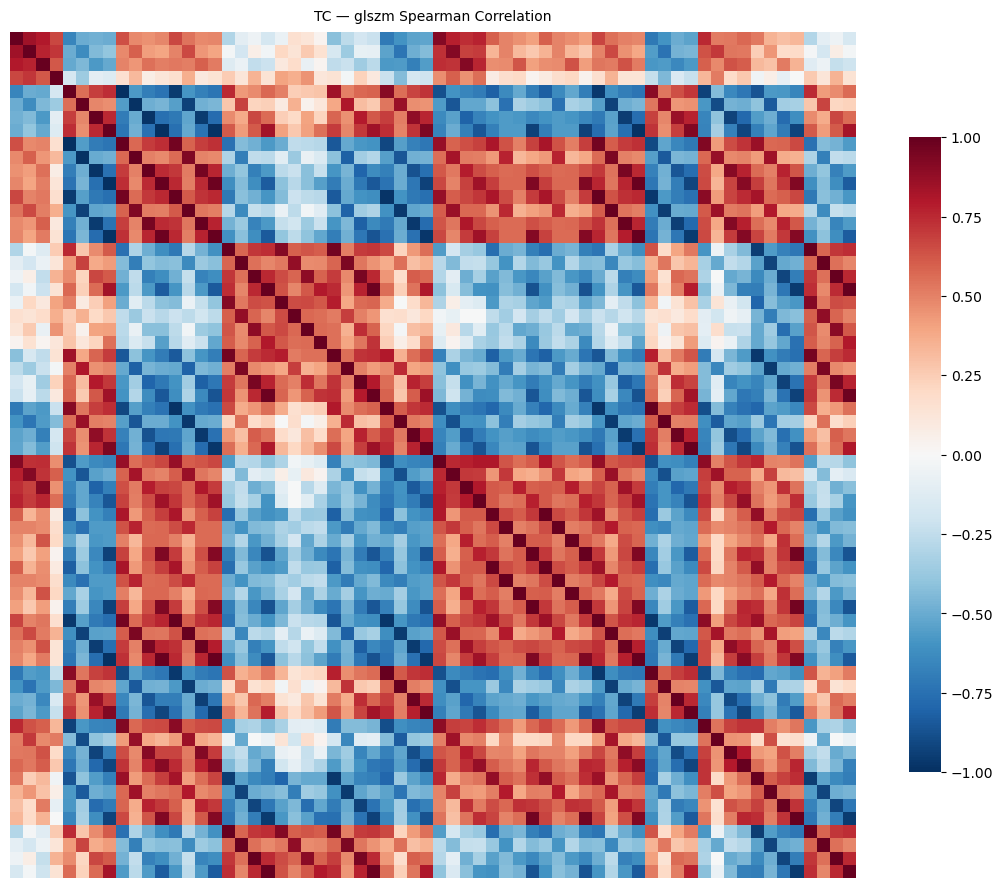

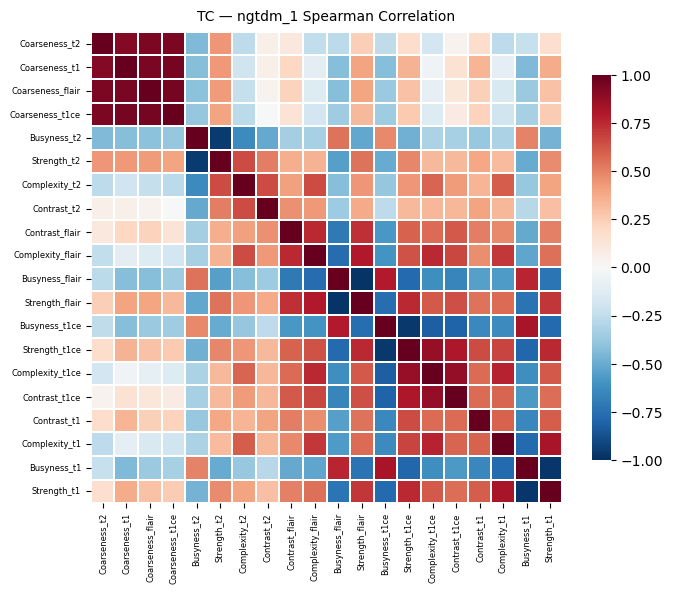

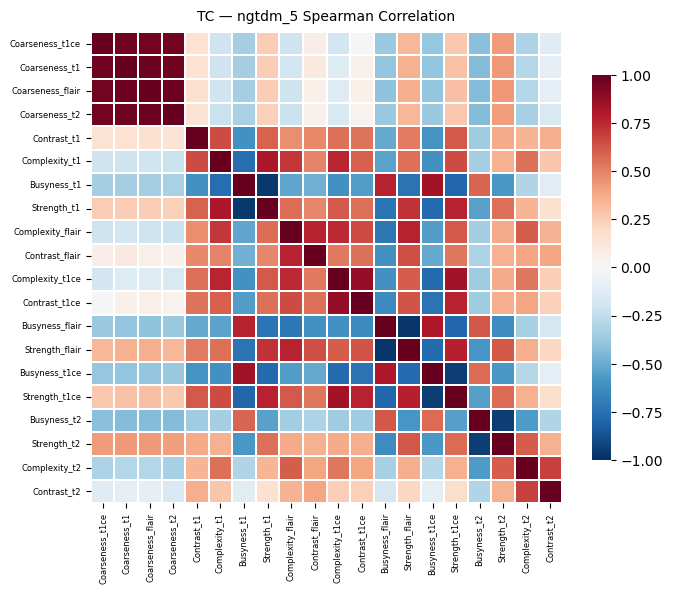

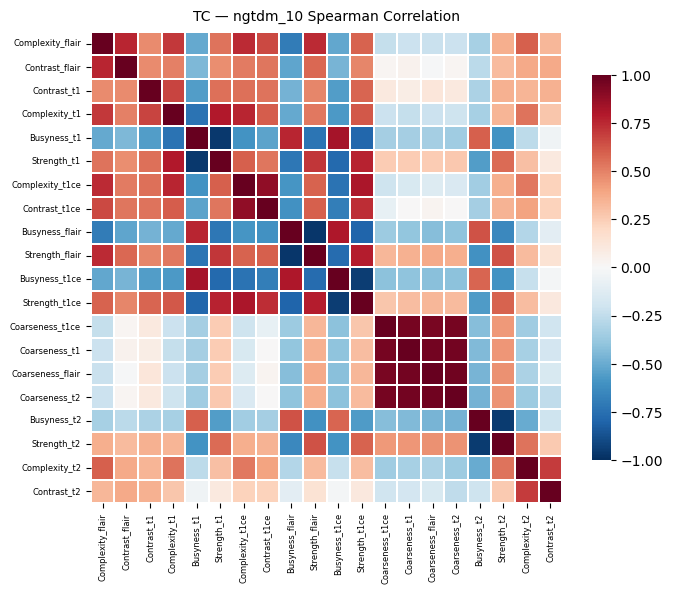

Saved: ../../Results/Figures/correlation_tc_all_families.pdf


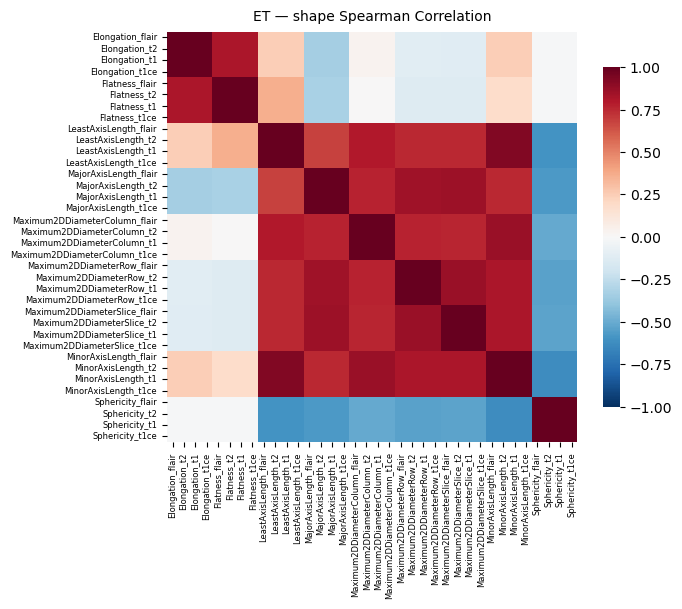

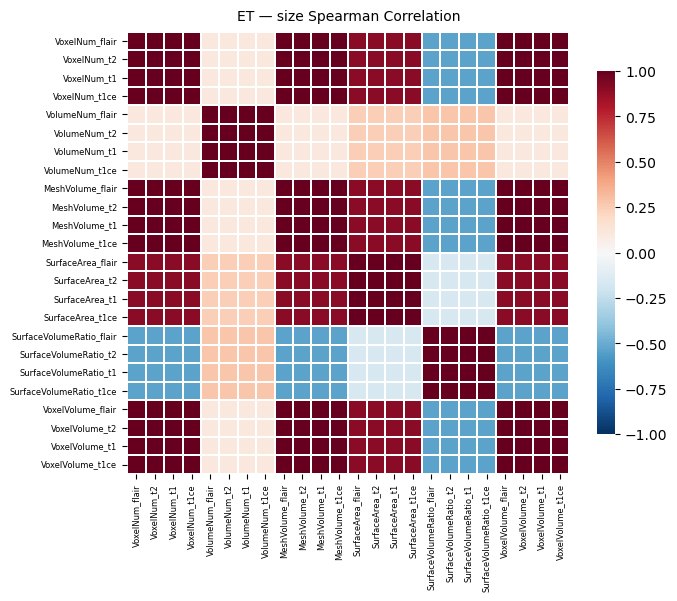

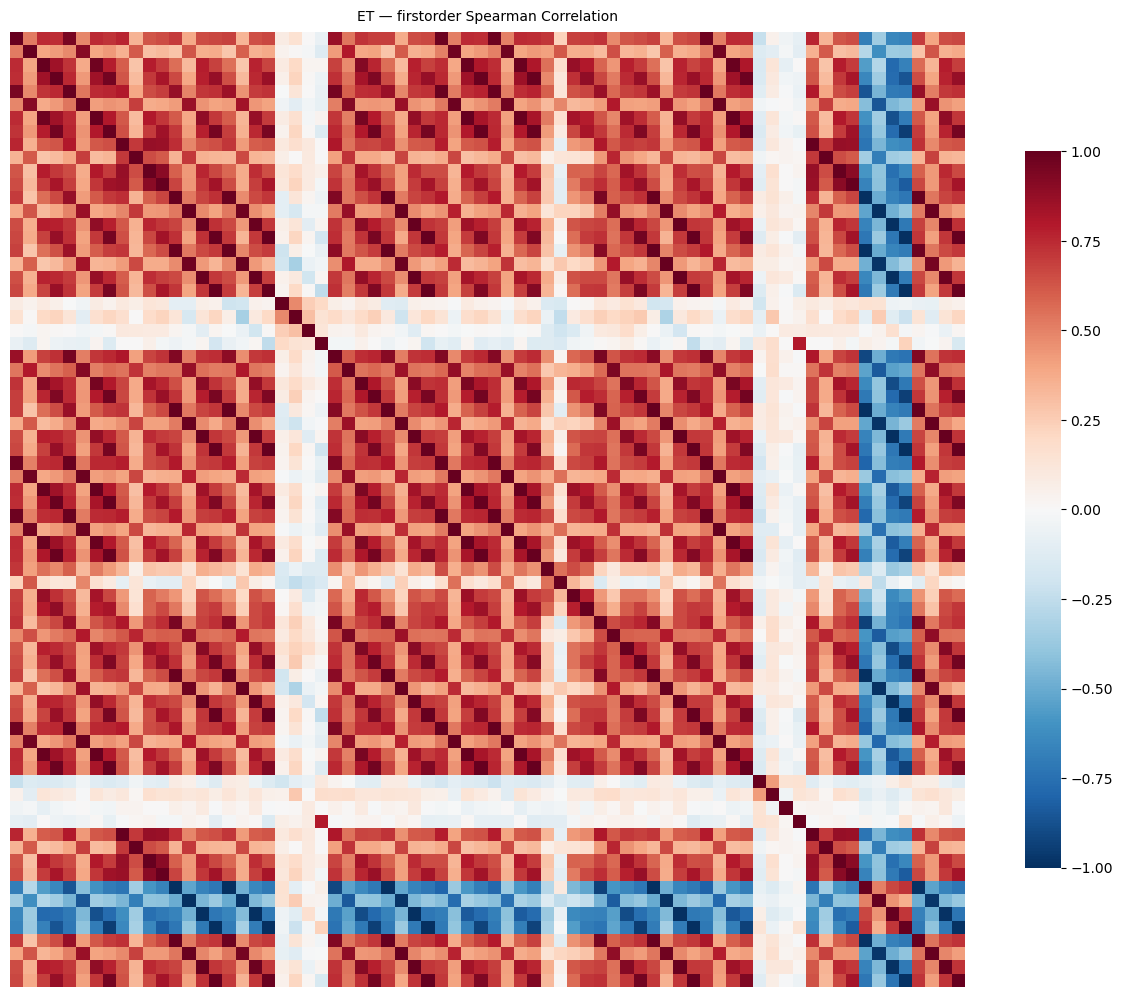

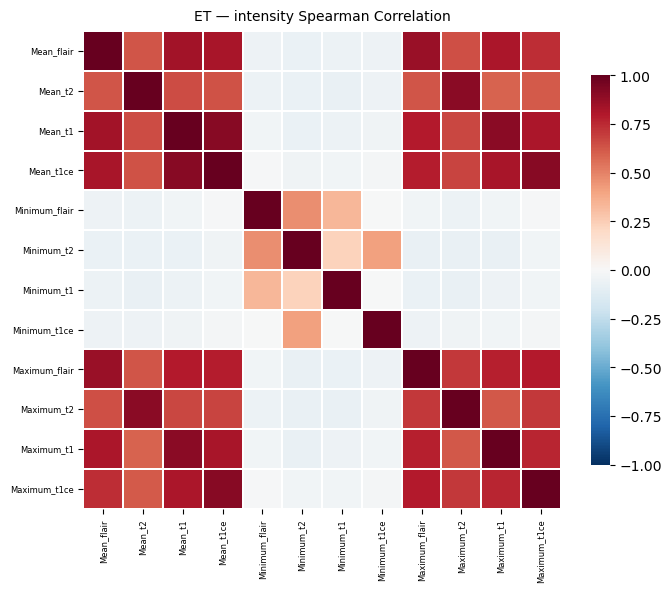

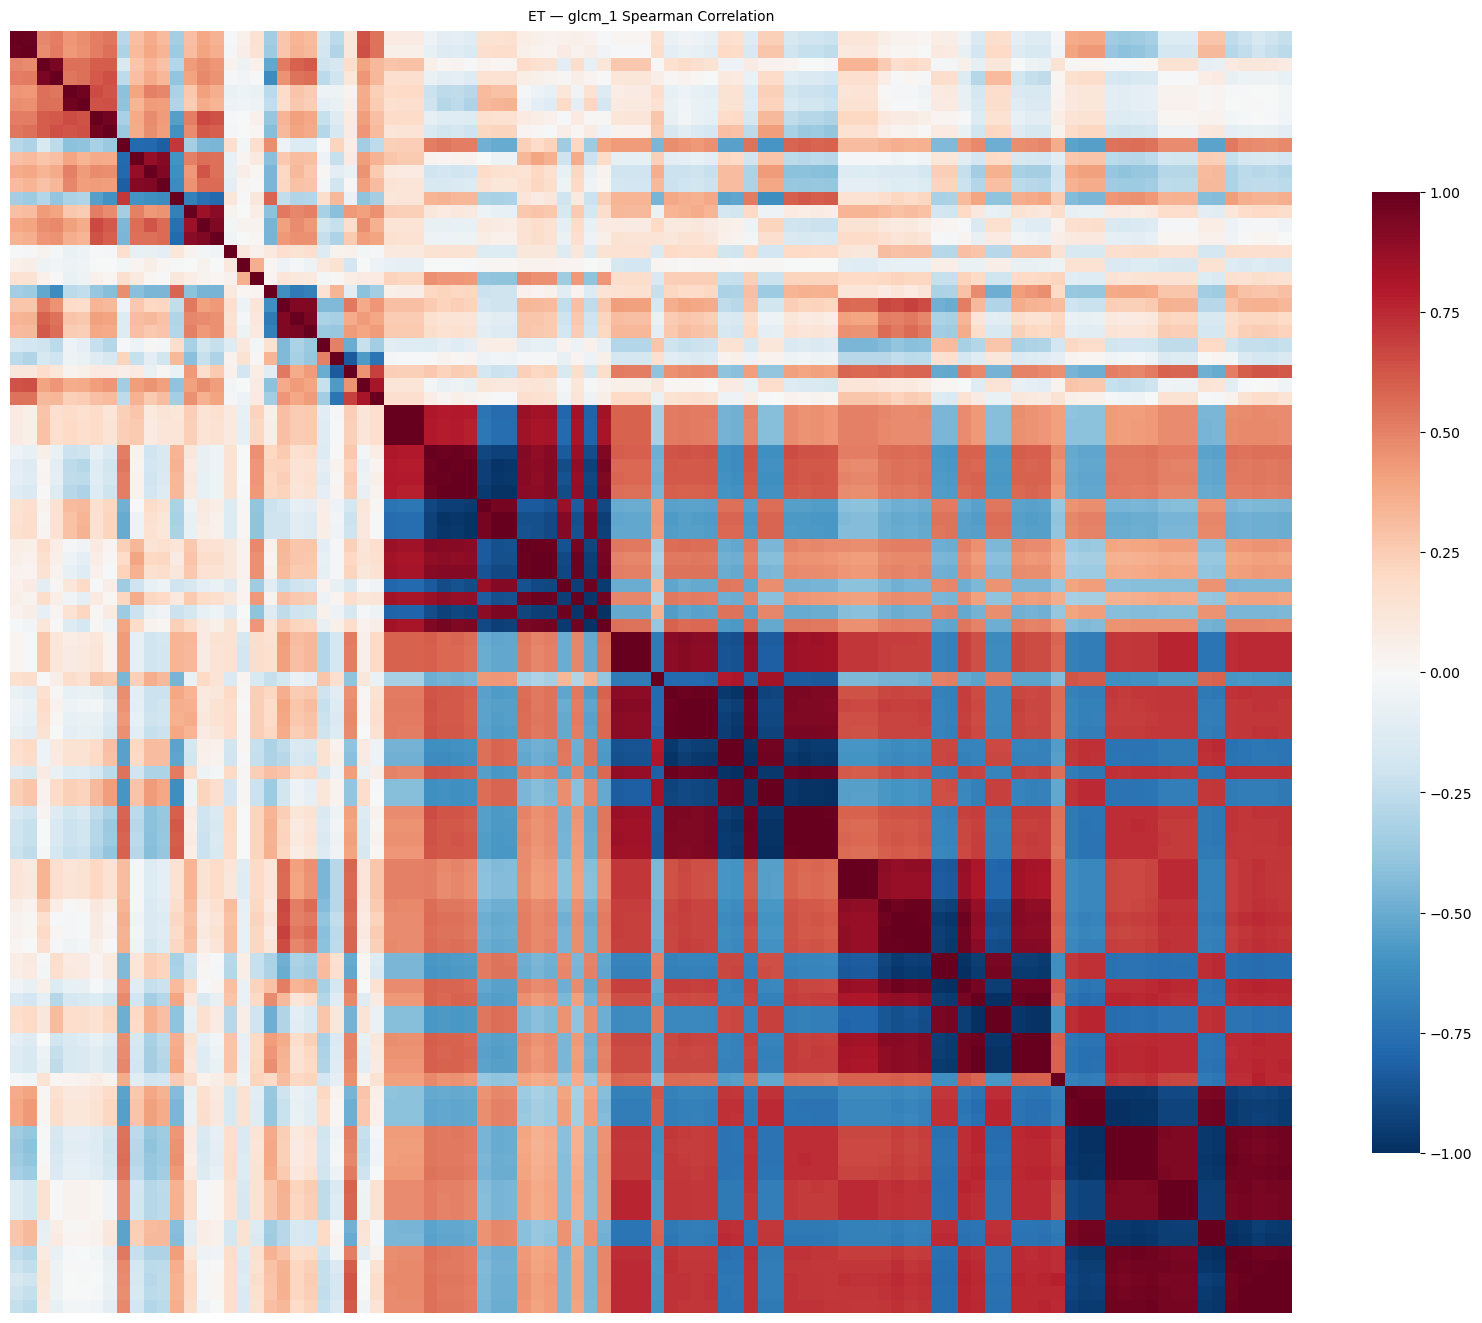

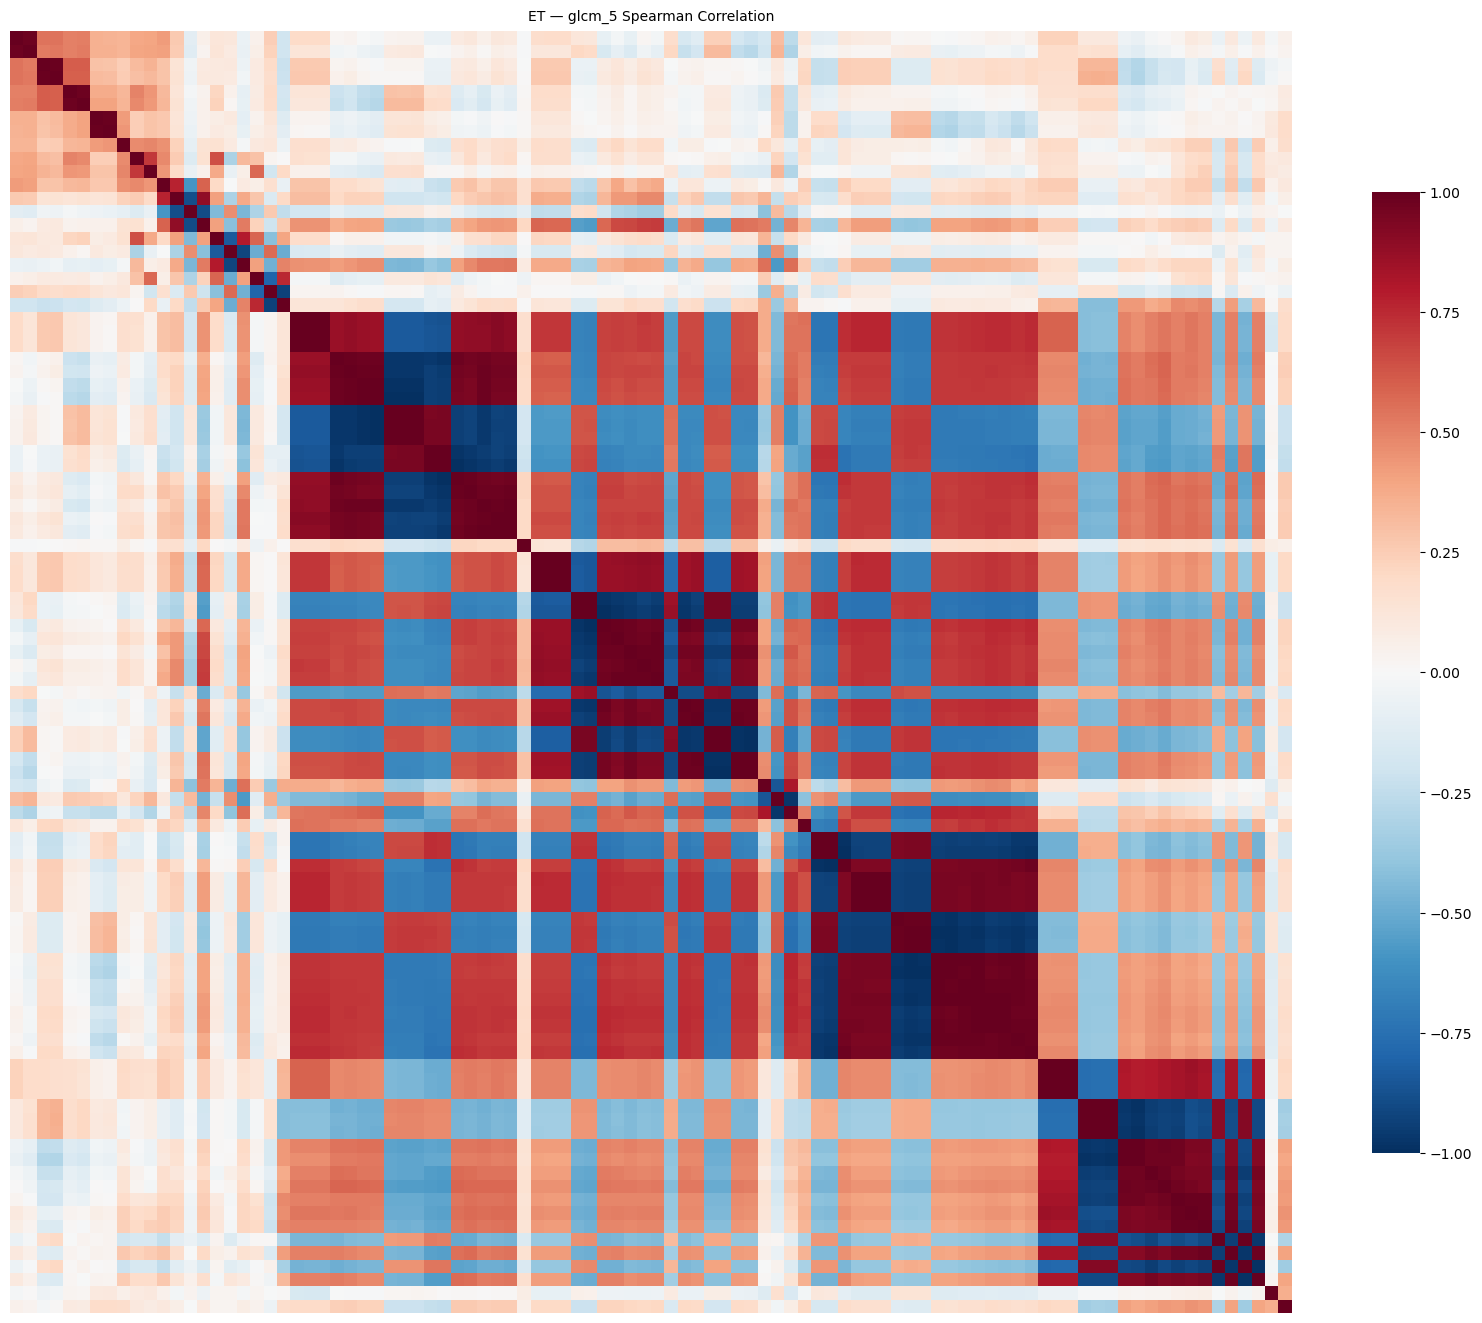

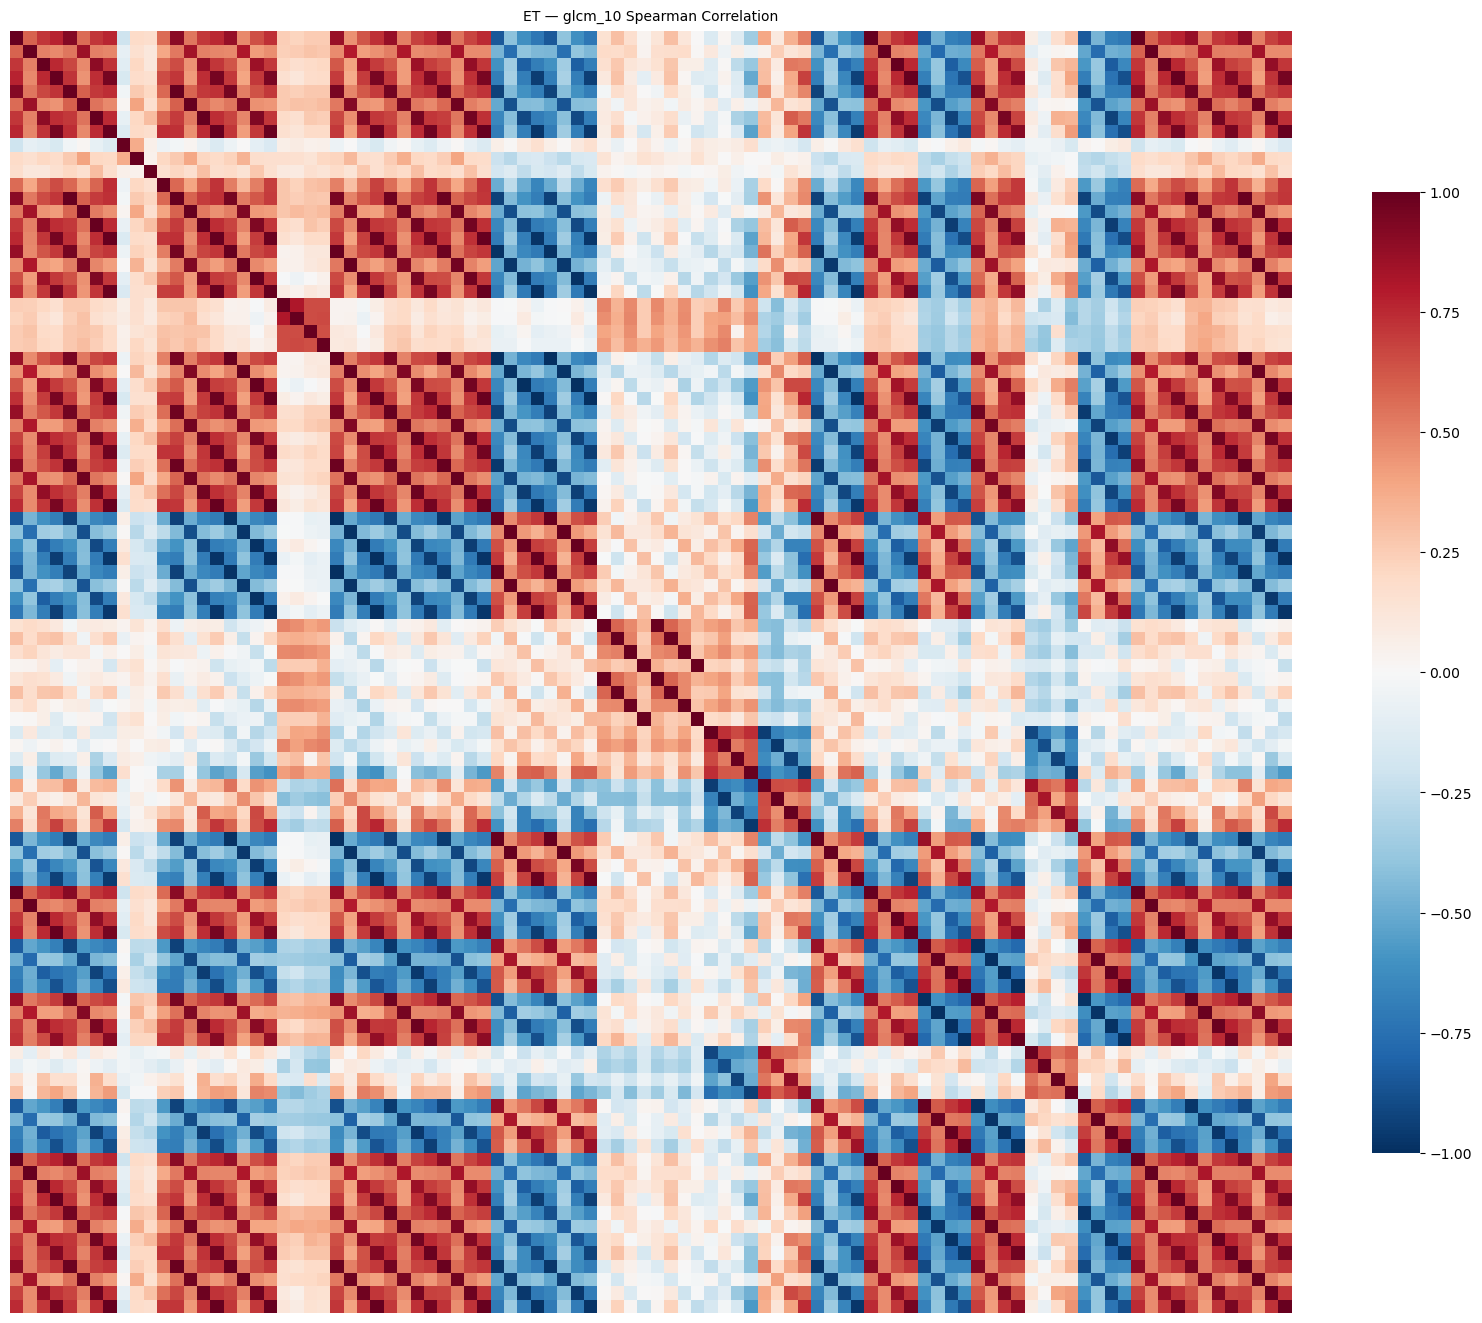

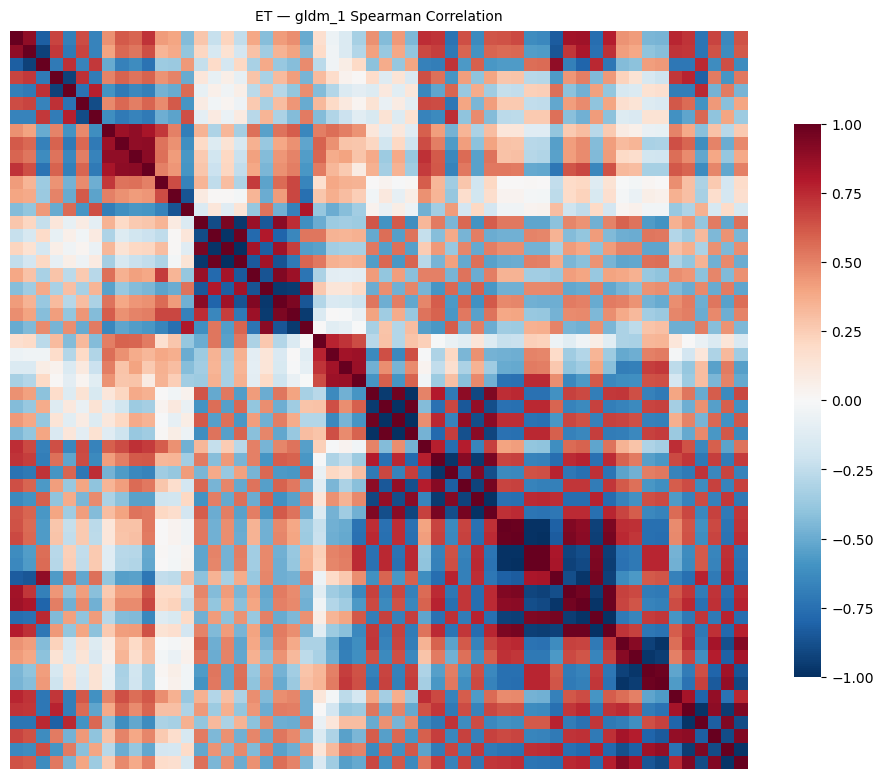

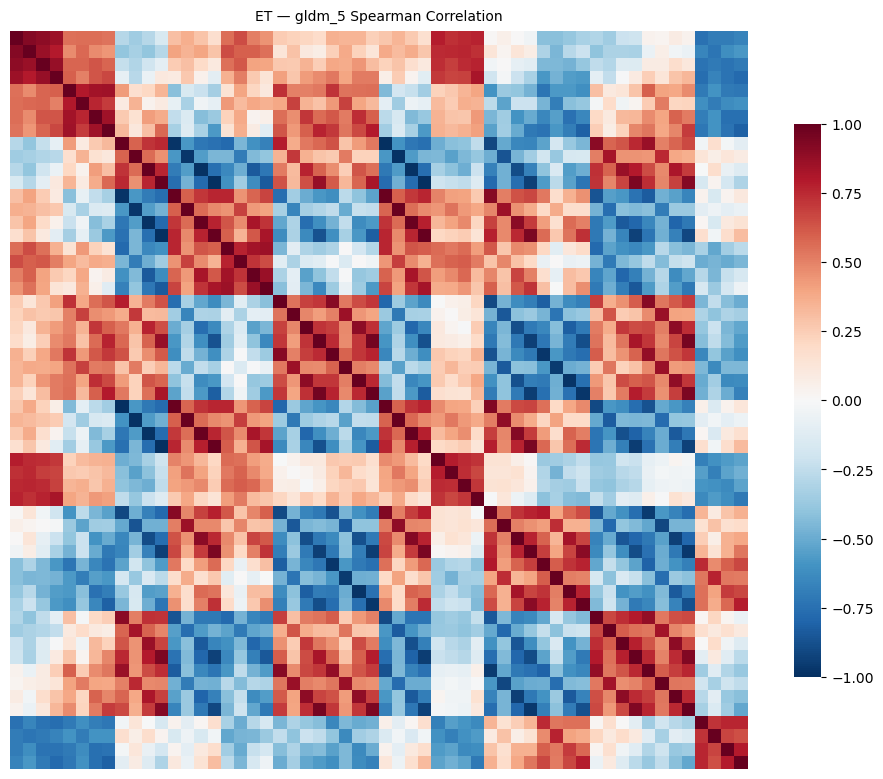

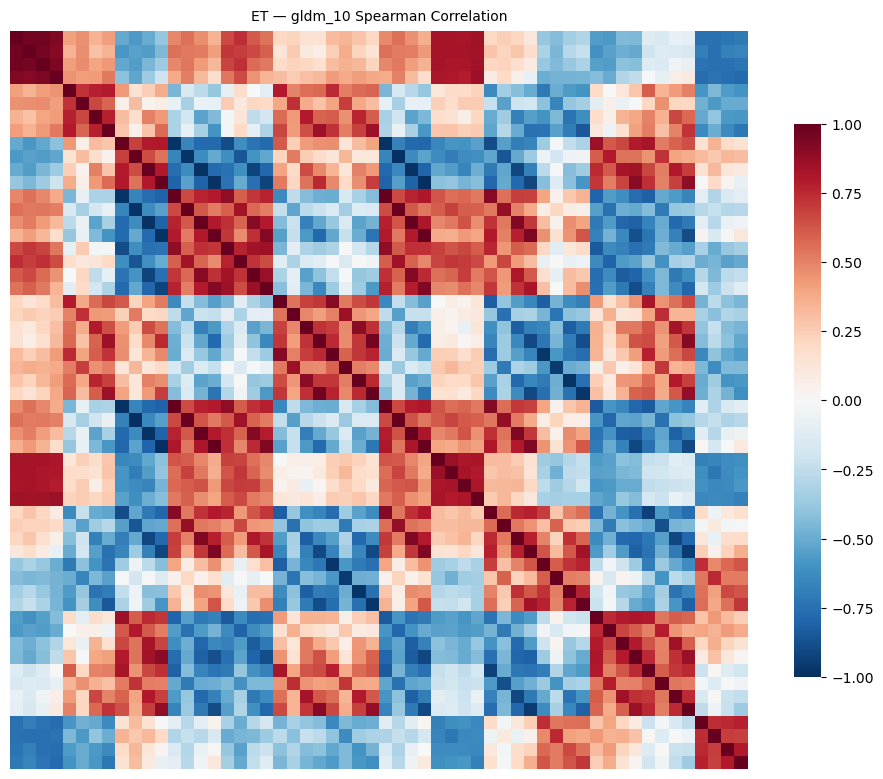

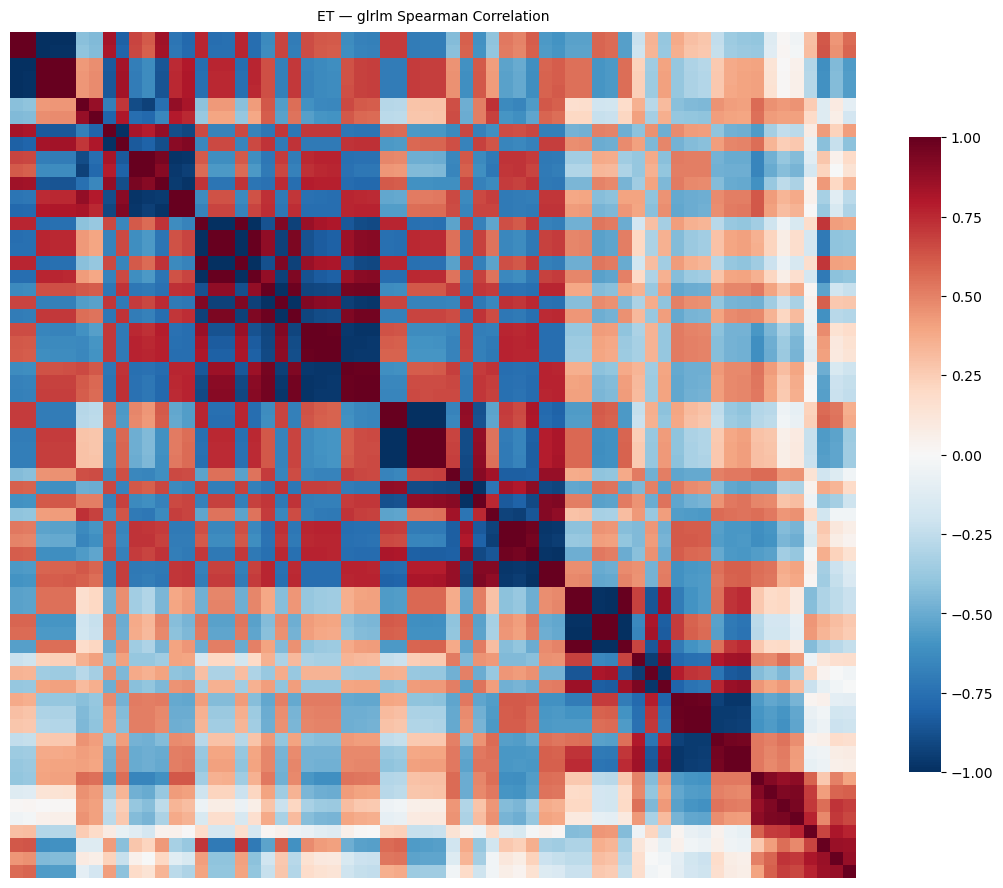

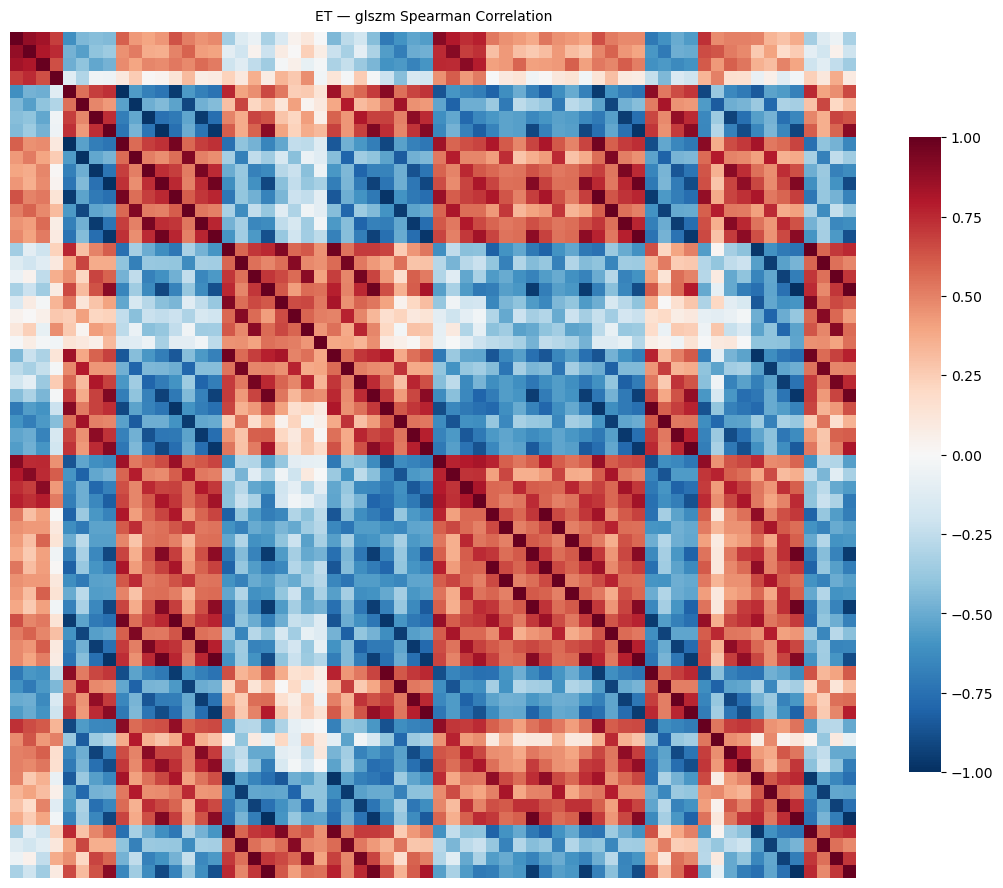

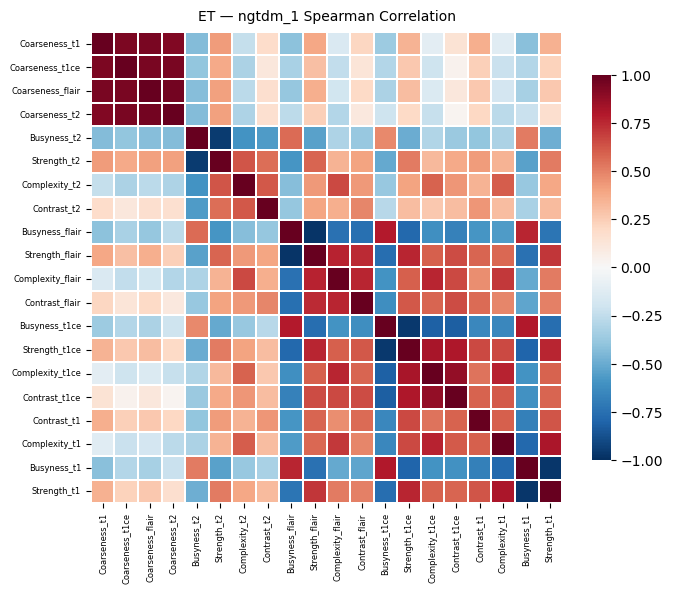

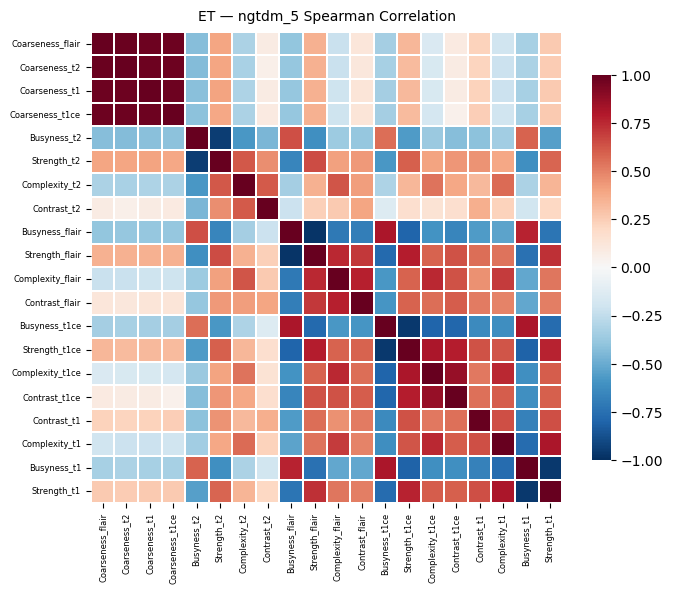

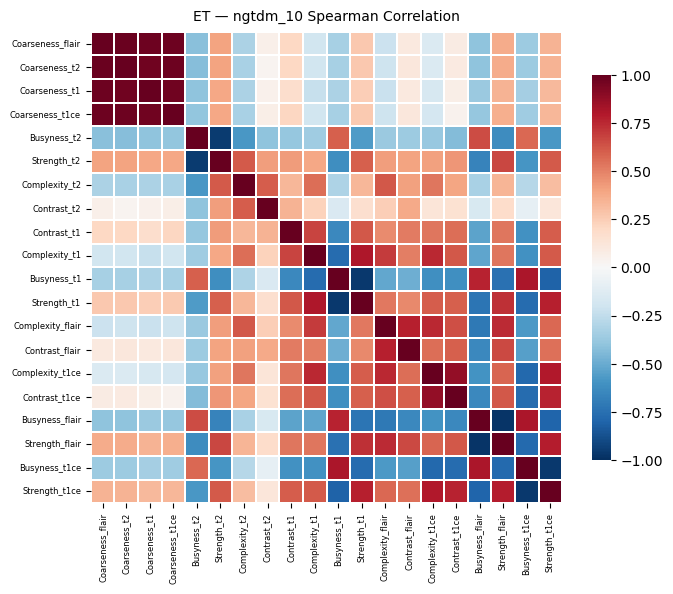

Saved: ../../Results/Figures/correlation_et_all_families.pdf


In [17]:
# Generate one PDF per subregion containing all family heatmaps
for sr in SUBREGIONS:
    sr_label = SR_LABELS[sr]
    out_path = f'../../Results/Figures/correlation_{sr_label.lower()}_all_families.pdf'
    with PdfPages(out_path) as pdf:
        for fam in FAMILIES:
            try:
                df = load_radiomics(sr, fam)
            except FileNotFoundError:
                continue
            corr_df, clean = spearman_matrix(df)
            if clean.shape[1] < 2:
                continue
            fig = clustered_heatmap(corr_df, f'{sr_label} — {fam} Spearman Correlation')
            pdf.savefig(fig, bbox_inches='tight')
            plt.show()
            plt.close(fig)
    print(f'Saved: {out_path}')

## Section 2 — Cross-Subregion Correlation
For each feature family, how correlated is the same feature extracted from WT vs TC vs ET?
High cross-subregion correlation means the three subregion features are largely redundant.

In [28]:
print('Cross-subregion correlation (same family, WT vs TC vs ET)')
print('=' * 70)

cross_sr_summary = {}

for fam in FAMILIES:
    try:
        wt = load_radiomics('Tumor_WT', fam)
        tc = load_radiomics('Tumor_TC', fam)
        et = load_radiomics('Tumor_ET', fam)
    except FileNotFoundError:
        continue

    # Rename columns with subregion suffix to distinguish them
    wt = wt.add_suffix('__WT')
    tc = tc.add_suffix('__TC')
    et = et.add_suffix('__ET')

    combined = wt.join(tc, how='inner').join(et, how='inner')
    combined = combined.apply(pd.to_numeric, errors='coerce').dropna()
    if combined.shape[1] < 2:
        continue

    corr_df, _ = spearman_matrix(combined)

    # Extract only cross-subregion pairs (e.g., Mean_flair__WT vs Mean_flair__TC)
    wt_cols = [c for c in corr_df.columns if c.endswith('__WT')]
    tc_cols = [c for c in corr_df.columns if c.endswith('__TC')]
    et_cols = [c for c in corr_df.columns if c.endswith('__ET')]

    # Compute mean |r| for WT-TC, WT-ET, TC-ET pairs
    def mean_cross_r(cols_a, cols_b):
        rs = [abs(corr_df.loc[a, b])
              for a, b in zip(cols_a, cols_b)
              if a in corr_df.index and b in corr_df.columns]
        return round(float(np.mean(rs)), 4) if rs else None

    wt_tc = mean_cross_r(wt_cols, tc_cols)
    wt_et = mean_cross_r(wt_cols, et_cols)
    tc_et = mean_cross_r(tc_cols, et_cols)

    print(f'{fam:15s}  mean|r| WT-TC={wt_tc:.3f}  WT-ET={wt_et:.3f}  TC-ET={tc_et:.3f}')
    cross_sr_summary[fam] = {'WT_TC': wt_tc, 'WT_ET': wt_et, 'TC_ET': tc_et}

summary['CrossSubregion'] = cross_sr_summary

Cross-subregion correlation (same family, WT vs TC vs ET)
shape            mean|r| WT-TC=0.522  WT-ET=0.470  TC-ET=0.849
size             mean|r| WT-TC=0.634  WT-ET=0.511  TC-ET=0.734
firstorder       mean|r| WT-TC=0.876  WT-ET=0.862  TC-ET=0.940
intensity        mean|r| WT-TC=1.000  WT-ET=1.000  TC-ET=1.000
glcm_1           mean|r| WT-TC=0.847  WT-ET=0.815  TC-ET=0.902
glcm_5           mean|r| WT-TC=0.811  WT-ET=0.766  TC-ET=0.890
glcm_10          mean|r| WT-TC=0.808  WT-ET=0.767  TC-ET=0.900
gldm_1           mean|r| WT-TC=0.881  WT-ET=0.837  TC-ET=0.909
gldm_5           mean|r| WT-TC=0.834  WT-ET=0.766  TC-ET=0.852
gldm_10          mean|r| WT-TC=0.806  WT-ET=0.739  TC-ET=0.852
glrlm            mean|r| WT-TC=0.897  WT-ET=0.865  TC-ET=0.931
glszm            mean|r| WT-TC=0.902  WT-ET=0.868  TC-ET=0.936
ngtdm_1          mean|r| WT-TC=0.858  WT-ET=0.829  TC-ET=0.939
ngtdm_5          mean|r| WT-TC=0.859  WT-ET=0.827  TC-ET=0.923
ngtdm_10         mean|r| WT-TC=0.858  WT-ET=0.824  TC-ET=0.9

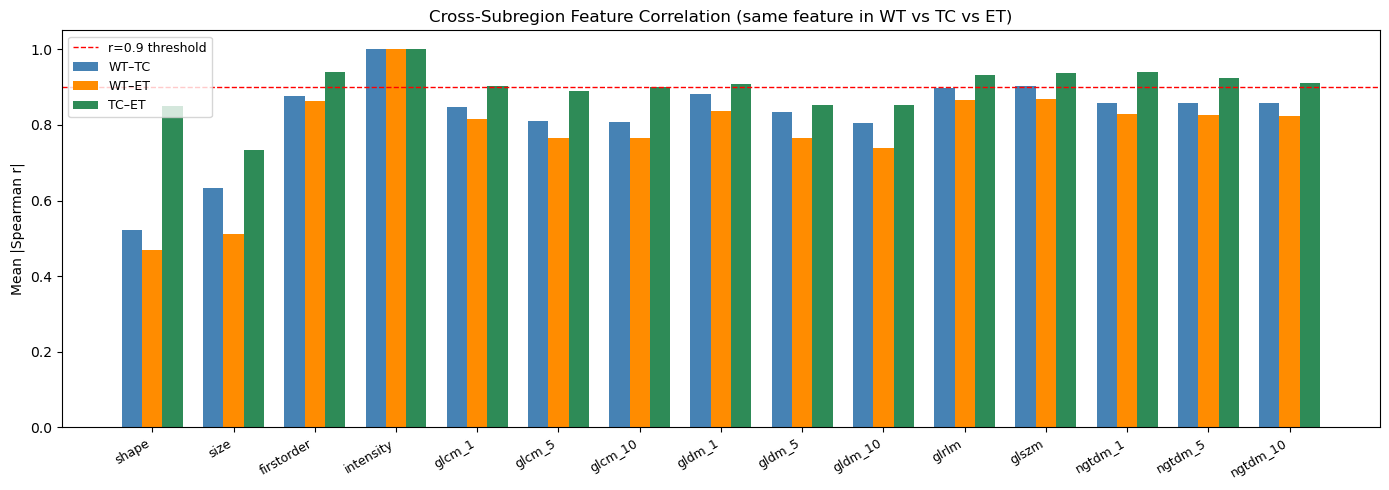

Saved: ../../Results/Figures/correlation_cross_subregion.pdf


In [19]:
# Plot cross-subregion mean |r| as grouped bar chart
fams   = list(cross_sr_summary.keys())
wt_tc_vals = [cross_sr_summary[f]['WT_TC'] or 0 for f in fams]
wt_et_vals = [cross_sr_summary[f]['WT_ET'] or 0 for f in fams]
tc_et_vals = [cross_sr_summary[f]['TC_ET'] or 0 for f in fams]

x = np.arange(len(fams))
w = 0.25
fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x - w, wt_tc_vals, w, label='WT–TC', color='steelblue')
ax.bar(x,     wt_et_vals, w, label='WT–ET', color='darkorange')
ax.bar(x + w, tc_et_vals, w, label='TC–ET', color='seagreen')
ax.axhline(0.9, color='red', linestyle='--', linewidth=1, label='r=0.9 threshold')
ax.set_xticks(x)
ax.set_xticklabels(fams, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Mean |Spearman r|')
ax.set_title('Cross-Subregion Feature Correlation (same feature in WT vs TC vs ET)')
ax.legend(fontsize=9)
plt.tight_layout()
fig.savefig('../../Results/Figures/correlation_cross_subregion.pdf', bbox_inches='tight')
plt.show()
print('Saved: ../../Results/Figures/correlation_cross_subregion.pdf')

## Section 3 — Oracle Input Features Correlation
Load the exact 258 features fed into the Oracle model and analyze their pairwise correlation.

In [20]:
# Load the significant feature lists (the Oracle input)
oracle_feature_files = {
    'shape':       '../../Results/features_shape.pkl',
    'size':        '../../Results/features_size.pkl',
    'intensity':   '../../Results/features_intensity.pkl',
    'ngtdm_10':    '../../Results/features_ngtdm_10.pkl',
    'saliency':    '../../Results/features_Saliency.pkl',
    'probability': '../../Results/features_Probability.pkl',
    'curvature':   '../../Results/features_Curverature.pkl',
    'volume':      '../../Results/features_volume.pkl',
}

oracle_feature_names = []
for name, path in oracle_feature_files.items():
    with open(path, 'rb') as f:
        feats = pkl.load(f)
    print(f'{name:12s}: {len(feats)} features')
    oracle_feature_names.extend(feats)

print(f'\nTotal Oracle features: {len(oracle_feature_names)}')

shape       : 5 features
size        : 2 features
intensity   : 6 features
ngtdm_10    : 10 features
saliency    : 6 features
probability : 5 features
curvature   : 4 features
volume      : 2 features

Total Oracle features: 40


In [21]:
# Load all raw feature data and build Oracle feature matrix
all_data_frames = []

for sr in SUBREGIONS:
    for fam in FAMILIES:
        try:
            all_data_frames.append(load_radiomics(sr, fam))
        except FileNotFoundError:
            pass

# Saliency and probability (model-based)
all_data_frames.append(pd.read_csv('../../Results/Analysis_Results/Saliency/Saliency.csv', index_col=0))
all_data_frames.append(pd.read_csv('../../Results/Analysis_Results/probability/Probability_Tumor_boundary.csv', index_col=0))

# Curvature — rename 'neg' → 'neg_count' to match Oracle feature naming
curv_df = pd.read_csv('../../Results/Analysis_Results/curverature/curverature_count_WT.csv', index_col='Unnamed: 0')
curv_df = curv_df[['mean_gaussian_curvature', 'std_gaussian_curvature', 'pos_count', 'neg']].rename(columns={'neg': 'neg_count'})
all_data_frames.append(curv_df)

# Volume (columns are already named 'NCR' and 'WT_volume')
vol_df = pd.read_csv('../../Results/Analysis_Results/volume/GLI-Tumor_volumns.csv', index_col='Unnamed: 0')
all_data_frames.append(vol_df[['NCR', 'WT_volume']])

# Concatenate all. Use first occurrence for duplicate column names (same feature from different subregions).
full_df = pd.concat(all_data_frames, axis=1)
full_df = full_df.loc[:, ~full_df.columns.duplicated(keep='first')]
print(f'Full feature matrix: {full_df.shape}')

# Subset to Oracle features that exist in the matrix
available_oracle = [f for f in oracle_feature_names if f in full_df.columns]
missing_oracle   = [f for f in oracle_feature_names if f not in full_df.columns]
print(f'Oracle features found:   {len(available_oracle)}/{len(oracle_feature_names)}')
if missing_oracle:
    print(f'  Still missing: {missing_oracle}')

oracle_df = full_df[available_oracle].apply(pd.to_numeric, errors='coerce').dropna()
print(f'Oracle matrix (clean):  {oracle_df.shape}')

Full feature matrix: (1251, 815)
Oracle features found:   40/40
Oracle matrix (clean):  (938, 40)


In [22]:
# Correlation among Oracle features
oracle_corr, _ = spearman_matrix(oracle_df)
oracle_pairs   = high_corr_pairs(oracle_corr, THRESHOLD)
oracle_drop    = greedy_drop(oracle_corr, THRESHOLD)
oracle_keep    = [f for f in available_oracle if f not in oracle_drop]

print(f'Oracle features:              {len(available_oracle)}')
print(f'High-corr pairs (|r|>={THRESHOLD}):  {len(oracle_pairs)}')
print(f'Suggested drops:              {len(oracle_drop)}')
print(f'Retained (de-correlated):     {len(oracle_keep)}')

SEP115 = '-' * 115
print('\nTop 10 correlated Oracle feature pairs:')
print(f'{"Feature A":50s}  {"Feature B":50s}  {"r":>8}')
print(SEP115)
for a, b, r in oracle_pairs[:10]:
    sa = '_'.join(a.split('_')[2:5])
    sb = '_'.join(b.split('_')[2:5])
    print(f'{sa:50s}  {sb:50s}  {r:8.4f}')


Oracle features:              40
High-corr pairs (|r|>=0.9):  15
Suggested drops:              10
Retained (de-correlated):     30

Top 10 correlated Oracle feature pairs:
Feature A                                           Feature B                                                  r
-------------------------------------------------------------------------------------------------------------------
VoxelVolume_flair_size                                                                                    1.0000
VoxelVolume_flair_size                              Coarseness_t1_ngtdm                                  -0.9737
Coarseness_t1_ngtdm                                                                                      -0.9737
Strength_flair_ngtdm                                Busyness_flair_ngtdm                                 -0.9685
Maximum_flair_intensity                             Complexity_flair_ngtdm                                0.9390
curvature                         

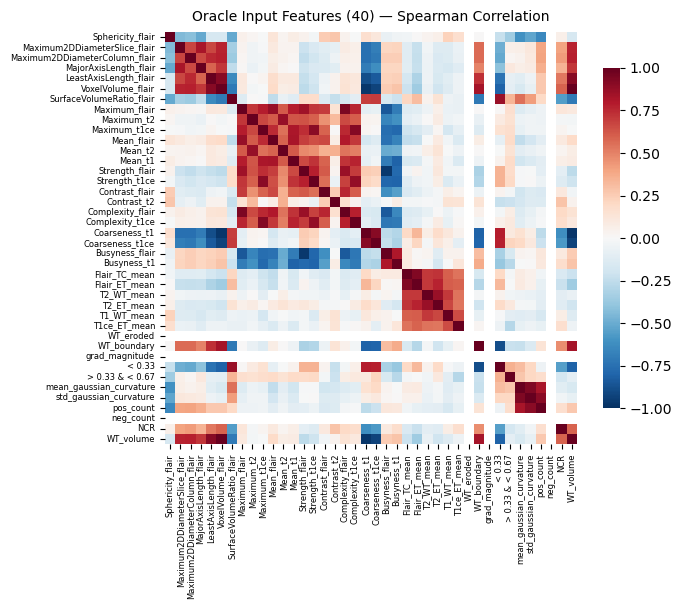

Saved: ../../Results/Figures/correlation_oracle_inputs.pdf


In [23]:
# Heatmap of Oracle features
fig = clustered_heatmap(oracle_corr, f'Oracle Input Features ({len(available_oracle)}) — Spearman Correlation')
fig.savefig('../../Results/Figures/correlation_oracle_inputs.pdf', bbox_inches='tight')
plt.show()
plt.close(fig)
print('Saved: ../../Results/Figures/correlation_oracle_inputs.pdf')

summary['OracleFeatures'] = {
    'n_features':        len(available_oracle),
    'n_high_corr_pairs': len(oracle_pairs),
    'n_suggested_drops': len(oracle_drop),
    'n_retained':        len(oracle_keep),
    'top_pairs':         [{'a': a, 'b': b, 'r': r} for a, b, r in oracle_pairs[:20]],
    'suggested_drops':   sorted(list(oracle_drop)),
    'retained_features': sorted(oracle_keep),
}

## Section 4 — VIF on Oracle Features
Variance Inflation Factor: values > 10 indicate severe multicollinearity.

In [24]:
print('Computing VIF on Oracle features (may take ~1 min)...')
vif_series = compute_vif(oracle_df)

print('\nVIF distribution:')
print(f'  > 100 (severe):   {(vif_series > 100).sum()}')
print(f'  10-100 (high):    {((vif_series > 10) & (vif_series <= 100)).sum()}')
print(f'  5-10 (moderate):  {((vif_series > 5)  & (vif_series <= 10)).sum()}')
print(f'  <= 5 (acceptable): {(vif_series <= 5).sum()}')

SEP75 = '-' * 75
print('\nTop 20 highest VIF features:')
print(f'{"Feature":60s}  {"VIF":>10}')
print(SEP75)
for feat, vif_val in vif_series.head(20).items():
    short = '_'.join(feat.split('_')[2:5])
    print(f'{short:60s}  {vif_val:10.1f}')

summary['VIF'] = {
    'n_severe_gt100':   int((vif_series > 100).sum()),
    'n_high_10_100':    int(((vif_series > 10) & (vif_series <= 100)).sum()),
    'n_moderate_5_10':  int(((vif_series > 5)  & (vif_series <= 10)).sum()),
    'n_acceptable_le5': int((vif_series <= 5).sum()),
    'top20': [{'feature': f, 'vif': float(v)} for f, v in vif_series.head(20).items()],
}


Computing VIF on Oracle features (may take ~1 min)...

VIF distribution:
  > 100 (severe):   2
  10-100 (high):    11
  5-10 (moderate):  8
  <= 5 (acceptable): 19

Top 20 highest VIF features:
Feature                                                              VIF
---------------------------------------------------------------------------
                                                              10000000000.0
VoxelVolume_flair_size                                        10000000000.0
Maximum_flair_intensity                                             27.8
Mean_flair_intensity                                                24.7
                                                                    19.9
Mean_t2_intensity                                                   17.0
Coarseness_t1_ngtdm                                                 16.6
curvature                                                           15.5
SurfaceVolumeRatio_flair_size                                      

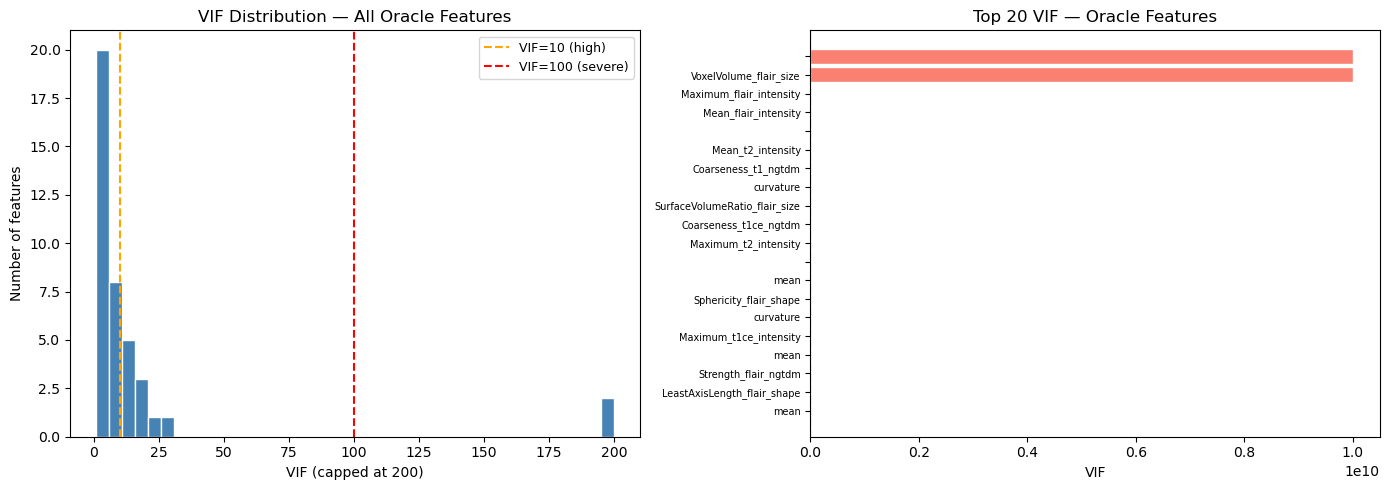

Saved: ../../Results/Figures/correlation_vif.pdf


In [25]:
# VIF histogram
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# All VIFs
axes[0].hist(vif_series.clip(upper=200), bins=40, color='steelblue', edgecolor='white')
axes[0].axvline(10,  color='orange', linestyle='--', label='VIF=10 (high)')
axes[0].axvline(100, color='red',    linestyle='--', label='VIF=100 (severe)')
axes[0].set_xlabel('VIF (capped at 200)')
axes[0].set_ylabel('Number of features')
axes[0].set_title('VIF Distribution — All Oracle Features')
axes[0].legend(fontsize=9)

# Top 20 VIF bar
top20 = vif_series.head(20)
short_labels = ['_'.join(f.split('_')[2:5]) for f in top20.index]
axes[1].barh(range(len(top20)), top20.values, color='salmon', edgecolor='white')
axes[1].set_yticks(range(len(top20)))
axes[1].set_yticklabels(short_labels, fontsize=7)
axes[1].axvline(10,  color='orange', linestyle='--')
axes[1].axvline(100, color='red',    linestyle='--')
axes[1].set_xlabel('VIF')
axes[1].set_title('Top 20 VIF — Oracle Features')
axes[1].invert_yaxis()

plt.tight_layout()
fig.savefig('../../Results/Figures/correlation_vif.pdf', bbox_inches='tight')
plt.show()
print('Saved: ../../Results/Figures/correlation_vif.pdf')

## Section 5 — De-correlated Oracle Feature Set
Save the retained features list after greedy de-correlation (|r| < 0.9).

In [26]:
with open('../../Results/features_oracle_decorrelated.pkl', 'wb') as f:
    pkl.dump(oracle_keep, f)

print(f'Saved de-correlated Oracle feature list: {len(oracle_keep)} features')
print('Path: ../../Results/features_oracle_decorrelated.pkl')
print('\nSample retained features:')
for feat in oracle_keep[:10]:
    print(f'  {feat}')

Saved de-correlated Oracle feature list: 30 features
Path: ../../Results/features_oracle_decorrelated.pkl

Sample retained features:
  original_shape_Sphericity_flair_shape
  original_shape_Maximum2DDiameterSlice_flair_shape
  original_shape_Maximum2DDiameterColumn_flair_shape
  original_shape_MajorAxisLength_flair_shape
  original_shape_LeastAxisLength_flair_shape
  original_shape_SurfaceVolumeRatio_flair_size
  diagnostics_Image-original_Maximum_flair_intensity
  diagnostics_Image-original_Maximum_t2_intensity
  diagnostics_Image-original_Mean_flair_intensity
  diagnostics_Image-original_Mean_t2_intensity


## Save Full JSON Summary

In [27]:
with open('../../Results/Json_summary/summary_correlations.json', 'w') as f:
    json.dump(summary, f, indent=4)

print('Saved: ../../Results/Json_summary/summary_correlations.json')

# Final summary printout
print('\n=== FINAL SUMMARY ===')
print(f'Subregions analyzed:      WT, TC, ET')
print(f'Feature families:         {len(FAMILIES)}')
print(f'Oracle input features:    {len(available_oracle)}')
print(f'High-corr Oracle pairs:   {len(oracle_pairs)}')
print(f'Suggested Oracle drops:   {len(oracle_drop)}')
print(f'De-correlated set size:   {len(oracle_keep)}')
print(f'VIF > 10 (Oracle):        {summary["VIF"]["n_severe_gt100"] + summary["VIF"]["n_high_10_100"]}')

Saved: ../../Results/Json_summary/summary_correlations.json

=== FINAL SUMMARY ===
Subregions analyzed:      WT, TC, ET
Feature families:         15
Oracle input features:    40
High-corr Oracle pairs:   15
Suggested Oracle drops:   10
De-correlated set size:   30
VIF > 10 (Oracle):        13
